In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import scipy
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
from collections import Counter
from Bio import Align
from Bio import SeqIO
from Bio.Align import PairwiseAligner
import pysam
from difflib import SequenceMatcher
import scipy.sparse as sp
import scipy.stats as stats
import statsmodels.formula.api as smf
import statsmodels.api as sm

sc.settings.verbosity = 2
# sc.logging.print_header()

# Load in exo vs endo adata

In [2]:
%%time

fpath = "/scratch/indikar_root/indikar1/shared_data/HYB/endo_vs_exo/processed_all_groups_wExoEndo_v2.h5ad"

adata = sc.read_h5ad(fpath)
adata

CPU times: user 717 ms, sys: 2.24 s, total: 2.95 s
Wall time: 11 s


AnnData object with n_obs × n_vars = 16296 × 25128
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# Extract endo/exo counts

In [3]:
### ------ get EXO/ENDO counts ------

adata.X = adata.layers['log_norm'].copy()


genes = ['MYOD1_exo', 'MYOD1_endo']

mdata = adata[:, genes].copy()
print(mdata.shape)


X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

df = pd.DataFrame(
        X,
        index=mdata.obs_names,
        columns=mdata.var_names,
    )


df = df.reset_index(names='cell_id')
print(df.shape)
df.head()


tmp = adata.obs[['pooled_condition', 'leiden_split', 'phase']].copy()

tmp = tmp.reset_index(names='cell_id')


df1 = pd.merge(df, tmp, how='left', on='cell_id')
print(df1.shape)
df1.head()

(16296, 2)
(16296, 3)
(16296, 6)


,cell_id,MYOD1_exo,MYOD1_endo,pooled_condition,leiden_split,phase
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,siPRRX1/mmMYOD1,H1,G2M
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,mmMYOD1,M1,S
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,siPRRX1/mmMYOD1,H1,G1
3,AAACCATTCACGTAAT_hybrid,0.000000,0.000000,siPRRX1,P1,G2M
4,AAACCATTCAGGCAGA_hybrid,0.000000,0.000000,siPRRX1,P1,G2M


# Linear regression (per condition)

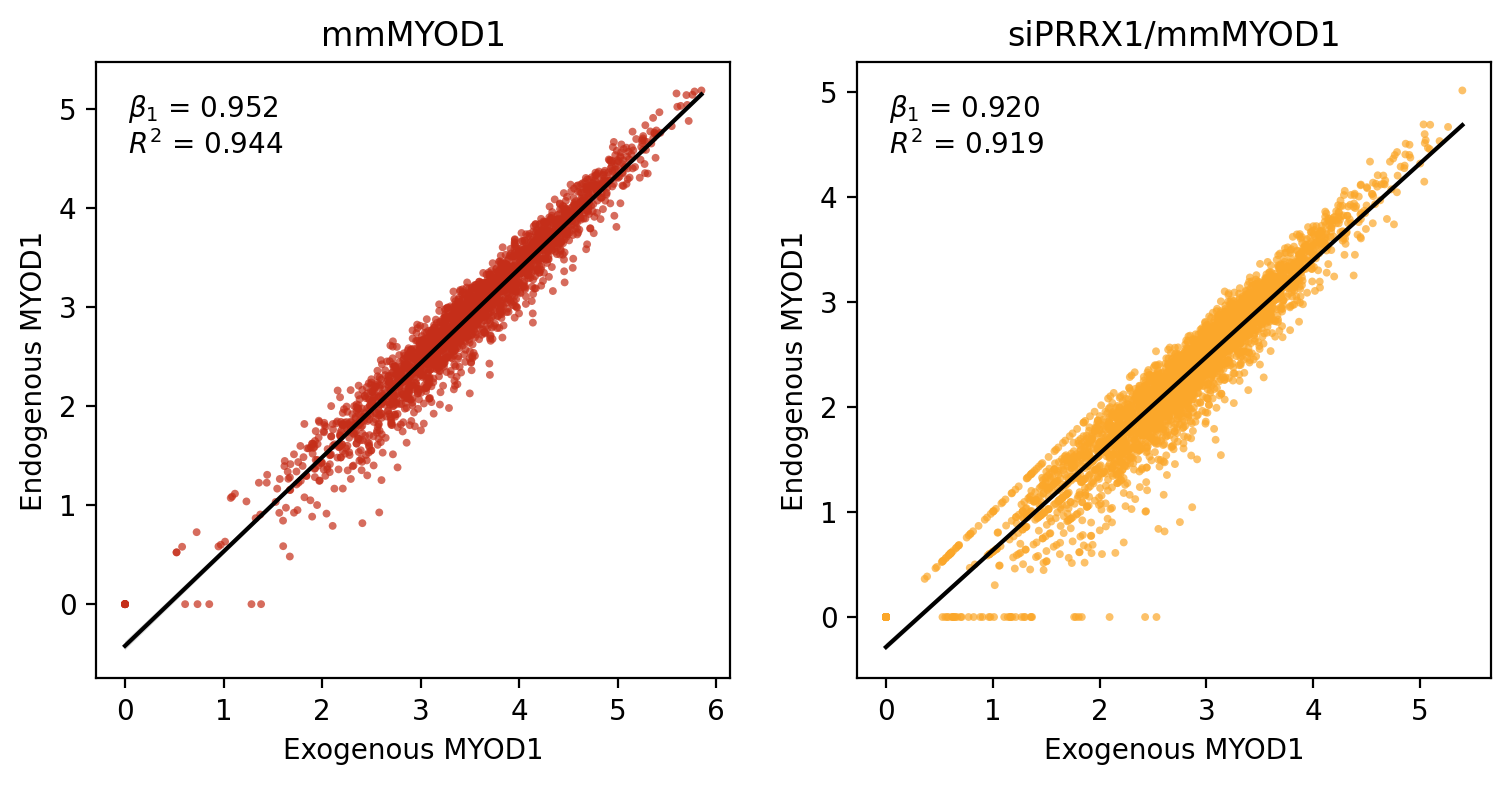

In [4]:
### ------ fit model per condition ------

conditions = ['mmMYOD1', 'siPRRX1/mmMYOD1']
cond_colors = ['#C52E19', '#FBA72A']


fig, axes = plt.subplots(1, 2, figsize=(9, 4), dpi=200)
axes = axes.flatten()


for i, cond in enumerate(conditions):
    ax = axes[i]

    
    tmp = df1[df1['pooled_condition'] == cond].copy()
    
    sns.regplot(
        data=tmp,
        x='MYOD1_exo',
        y='MYOD1_endo',
        scatter_kws={'s': 8, 'alpha': 0.7, 'edgecolor': 'none', 'color': cond_colors[i]},
        line_kws={'color': 'black', 'lw': 1.5},
        ci=95,
        n_boot=2000,
        ax=ax
    )
    
    ax.set_title(f'{cond}')
    ax.set_xlabel('Exogenous MYOD1')
    ax.set_ylabel('Endogenous MYOD1')
    
    # Fit regression -- answers: does exo MYOD1 predict endo MYOD1 expression?
    X = sm.add_constant(tmp['MYOD1_exo'])
    y = tmp['MYOD1_endo']
    model = sm.OLS(y, X).fit()

    r2 = model.rsquared
    pval = model.pvalues['MYOD1_exo']
    slope = model.params['MYOD1_exo']
    intercept = model.params['const']
    
    ax.text(
        0.05, 0.95,
        f'$β_1$ = {slope:.3f}\n$R^2$ = {r2:.3f}',
        transform=ax.transAxes,
        ha='left',
        va='top'
    )
    
#     if pval == 0:
#         p_text = 'p < 1e-300'
#     else:
#         p_text = f'p = {pval:.2e}'
    
#     ax.text(
#         0.05, 0.95,
#         f'$R^2$ = {r2:.3f}\n{p_text}',
#         transform=ax.transAxes,
#         ha='left',
#         va='top'
#     )

plt.show()

# Multiple linear regression

In [7]:
### ------ fit interaction model ------
conditions = ['mmMYOD1', 'siPRRX1/mmMYOD1']

# subset for conditions of interest
tmp = df1[df1['pooled_condition'].isin(conditions)].copy()
tmp['pooled_condition'] = tmp['pooled_condition'].astype(str)

# binary encoding
tmp['cond_binary'] = (tmp['pooled_condition'] == 'siPRRX1/mmMYOD1').astype(int)

# interaction term
tmp['interaction'] = tmp['MYOD1_exo'] * tmp['cond_binary']

# design matrix (IMPORTANT: consistent ordering)
X = tmp[['MYOD1_exo', 'cond_binary', 'interaction']]
X = sm.add_constant(X)

y = tmp['MYOD1_endo']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             MYOD1_endo   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                 2.925e+04
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:04:23   Log-Likelihood:                 370.16
No. Observations:                5711   AIC:                            -732.3
Df Residuals:                    5707   BIC:                            -705.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4213      0.020    -20.776      

In [8]:
x_grid = np.linspace(tmp['MYOD1_exo'].min(), tmp['MYOD1_exo'].max(), 100)

# mmMYOD1 (0)
X_mm = pd.DataFrame({
    'const': 1.0,
    'MYOD1_exo': x_grid,
    'cond_binary': 0
})
X_mm['interaction'] = X_mm['MYOD1_exo'] * X_mm['cond_binary']

# siPRRX1/mmMYOD1 (1)
X_si = pd.DataFrame({
    'const': 1.0,
    'MYOD1_exo': x_grid,
    'cond_binary': 1
})
X_si['interaction'] = X_si['MYOD1_exo'] * X_si['cond_binary']



pred_mm = model.get_prediction(X_mm)
mean_mm = pred_mm.predicted_mean
ci_mm = pred_mm.conf_int()

pred_si = model.get_prediction(X_si)
mean_si = pred_si.predicted_mean
ci_si = pred_si.conf_int()


# extract slopes
params = model.params

slope_mm = params['MYOD1_exo']
slope_si = params['MYOD1_exo'] + params['interaction']

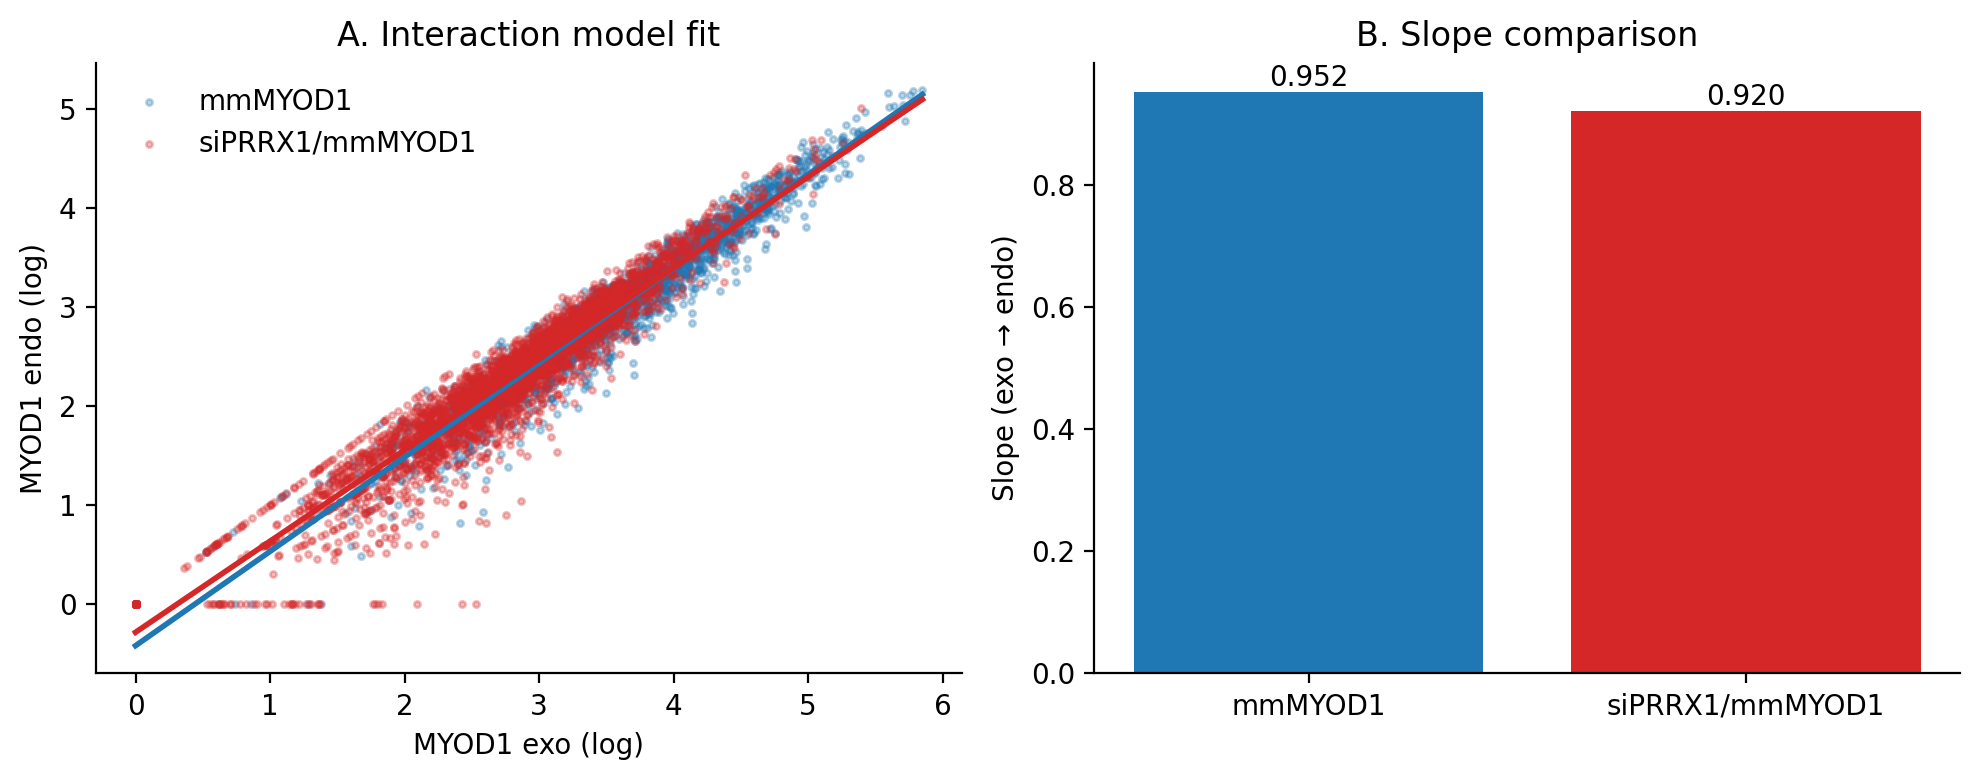

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=200)

# -----------------------
# Panel A: scatter + regression
# -----------------------
ax = axes[0]

# scatter
ax.scatter(
    tmp[tmp['cond_binary'] == 0]['MYOD1_exo'],
    tmp[tmp['cond_binary'] == 0]['MYOD1_endo'],
    s=5, alpha=0.3, color='tab:blue', label='mmMYOD1'
)

ax.scatter(
    tmp[tmp['cond_binary'] == 1]['MYOD1_exo'],
    tmp[tmp['cond_binary'] == 1]['MYOD1_endo'],
    s=5, alpha=0.3, color='tab:red', label='siPRRX1/mmMYOD1'
)

# regression lines
ax.plot(x_grid, mean_mm, color='tab:blue', linewidth=2)
ax.plot(x_grid, mean_si, color='tab:red', linewidth=2)

ax.set_xlabel("MYOD1 exo (log)")
ax.set_ylabel("MYOD1 endo (log)")
ax.set_title("A. Interaction model fit")
ax.legend(frameon=False)

# -----------------------
# Panel B: slope comparison
# -----------------------
ax = axes[1]

slopes = [slope_mm, slope_si]
labels = ['mmMYOD1', 'siPRRX1/mmMYOD1']
colors = ['tab:blue', 'tab:red']

ax.bar(labels, slopes, color=colors)

ax.set_ylabel("Slope (exo → endo)")
ax.set_title("B. Slope comparison")

# annotate values
for i, v in enumerate(slopes):
    ax.text(i, v, f"{v:.3f}", ha='center', va='bottom')

sns.despine()
plt.tight_layout()

                            OLS Regression Results                            
Dep. Variable:             MYOD1_endo   R-squared:                       0.939
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                 2.925e+04
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:05:20   Log-Likelihood:                 370.16
No. Observations:                5711   AIC:                            -732.3
Df Residuals:                    5707   BIC:                            -705.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4213      0.020    -20.776      

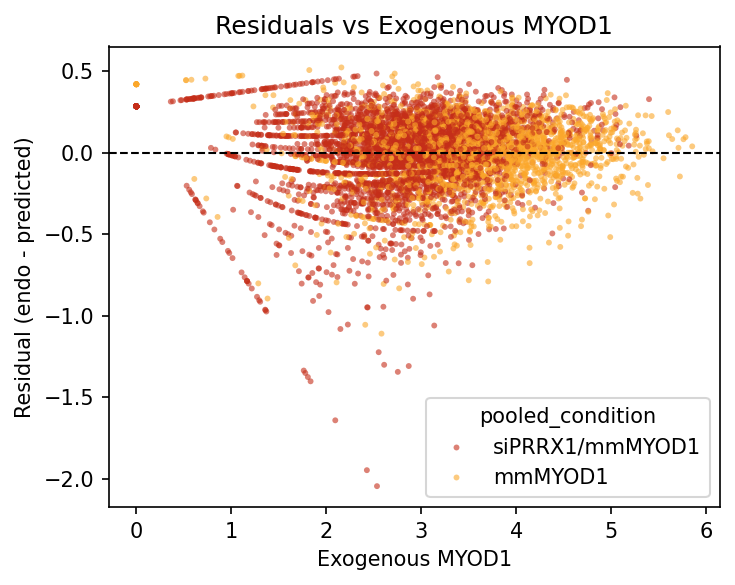

In [35]:
conditions = ['mmMYOD1', 'siPRRX1/mmMYOD1']
cond_colors = ['#C52E19', '#FBA72A']

# combine both conditions
tmp = df1[df1['pooled_condition'].isin(conditions)].copy()
tmp['pooled_condition'] = tmp['pooled_condition'].astype(str)


tmp['cond_binary'] = (tmp['pooled_condition'] == 'siPRRX1/mmMYOD1').astype(int)

X = sm.add_constant(tmp[['MYOD1_exo', 'cond_binary']])
X['interaction'] = tmp['MYOD1_exo'] * tmp['cond_binary']
y = tmp['MYOD1_endo']

model = sm.OLS(y, X).fit()
print(model.summary())


tmp['fitted'] = model.fittedvalues
tmp['residual'] = model.resid


plt.figure(figsize=(5, 4), dpi=150)

sns.scatterplot(
    data=tmp,
    x='MYOD1_exo',
    y='residual',
    hue='pooled_condition',
    s=8,
    alpha=0.6,
    edgecolor='none',
    palette=cond_colors,
)

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel('Exogenous MYOD1')
plt.ylabel('Residual (endo - predicted)')
plt.title('Residuals vs Exogenous MYOD1')

plt.tight_layout()
plt.show()

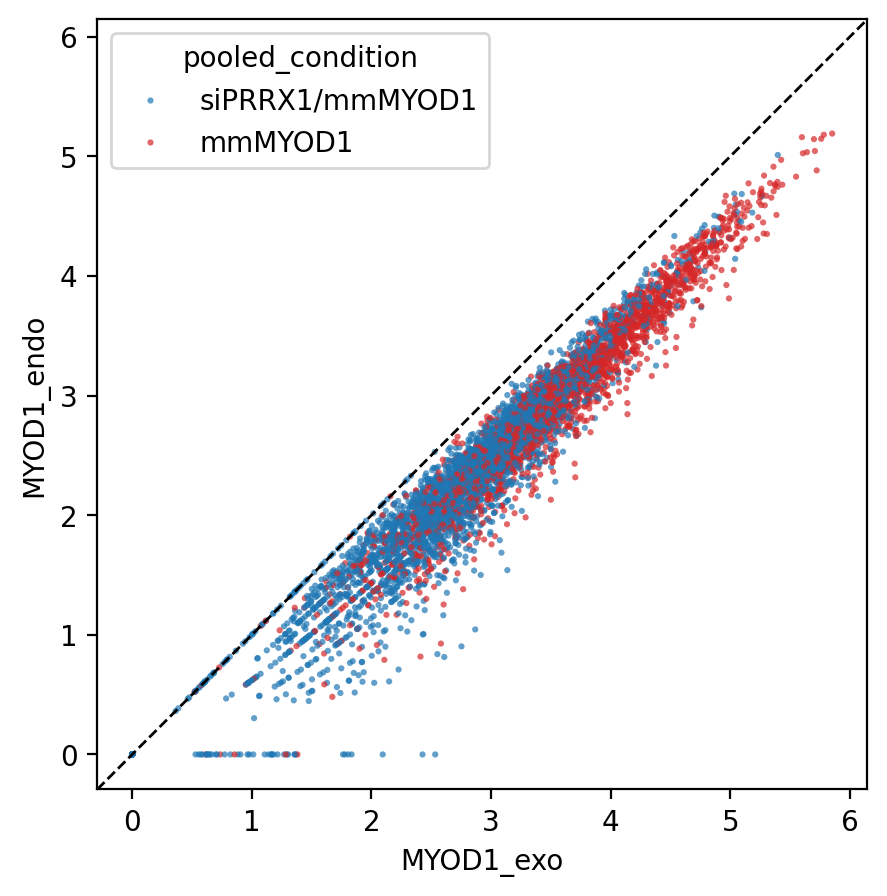

In [26]:
tmp = df1[df1['pooled_condition'].isin(conditions)].copy()

tmp['pooled_condition'] = tmp['pooled_condition'].astype(str)


ax = sns.scatterplot(
    data=tmp,
    x='MYOD1_exo',
    y='MYOD1_endo',
    s=5,
    hue='pooled_condition',
    ec='none',
    alpha=0.7,
    palette=['tab:blue', 'tab:red'],
)

# get limits
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# use the same range for both axes
low = min(xmin, ymin)
high = max(xmax, ymax)

# plot identity line
ax.plot([low, high], [low, high], linestyle='--', color='black', linewidth=1)

# (optional) enforce equal scaling so the line is truly 45°
ax.set_xlim(low, high)
ax.set_ylim(low, high)
ax.set_aspect('equal', adjustable='box')

# sns.scatterplot(
#     tmp,
#     x='MYOD1_exo',
#     y='MYOD1_endo',
#     s=5,
#     hue='pooled_condition',
#     ec='none',
#     alpha=0.7,
#     palette=['tab:blue', 'tab:red'],
# )


# # plt.gca().plot(1, 1, 

plt.show()

# Correlation

In [5]:
from scipy.stats import pearsonr, spearmanr

conditions = ['mmMYOD1', 'siPRRX1/mmMYOD1']

tmp = df1[df1['pooled_condition'].isin(conditions)].copy()
tmp['pooled_condition'] = tmp['pooled_condition'].astype(str)

for cond in conditions:
    
    sub = tmp[tmp['pooled_condition'] == cond].copy()
    
    sub = sub[['cell_id', 'MYOD1_exo', 'MYOD1_endo']]
    sub = sub.set_index('cell_id')
    
    r, p = pearsonr(sub['MYOD1_exo'], sub['MYOD1_endo'])
    print(f"{cond}: pearson r = {r:.4f}, p-val = {p:.2e}")
    
    
    r, p = spearmanr(sub['MYOD1_exo'], sub['MYOD1_endo'])
    print(f"{cond}: spearman r = {r:.4f}, p-val = {p:.2e}\n")
    
    
# across both
r, p = pearsonr(tmp['MYOD1_exo'], tmp['MYOD1_endo'])
print(f"All together: pearson r = {r:.4f}, p-val = {p:.2e}")

r, p = spearmanr(tmp['MYOD1_exo'], tmp['MYOD1_endo'])
print(f"All together: spearman r = {r:.4f}, p-val = {p:.2e}")

mmMYOD1: pearson r = 0.9717, p-val = 0.00e+00
mmMYOD1: spearman r = 0.9721, p-val = 0.00e+00

siPRRX1/mmMYOD1: pearson r = 0.9586, p-val = 0.00e+00
siPRRX1/mmMYOD1: spearman r = 0.9596, p-val = 0.00e+00

All together: pearson r = 0.9687, p-val = 0.00e+00
All together: spearman r = 0.9697, p-val = 0.00e+00


## With original MYOD1

Original MYOD1 meaning counts for MYOD1 from original EPI2ME run

In [6]:
### ------ get EXO/ENDO + regular MYOD1 counts ------

adata.X = adata.layers['log_norm'].copy()


genes = ['MYOD1_exo', 'MYOD1_endo', 'MYOD1']

mdata = adata[:, genes].copy()
print(mdata.shape)


X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

df = pd.DataFrame(
        X,
        index=mdata.obs_names,
        columns=mdata.var_names,
    )


df = df.reset_index(names='cell_id')
print(df.shape)
df.head()


tmp = adata.obs[['pooled_condition', 'leiden_split', 'phase']].copy()

tmp = tmp.reset_index(names='cell_id')


df1 = pd.merge(df, tmp, how='left', on='cell_id')
print(df1.shape)
df1.head()

(16296, 3)
(16296, 4)
(16296, 7)


,cell_id,MYOD1_exo,MYOD1_endo,MYOD1,pooled_condition,leiden_split,phase
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,2.299394,siPRRX1/mmMYOD1,H1,G2M
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,1.630238,mmMYOD1,M1,S
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,1.134289,siPRRX1/mmMYOD1,H1,G1
3,AAACCATTCACGTAAT_hybrid,0.000000,0.000000,0.000000,siPRRX1,P1,G2M
4,AAACCATTCAGGCAGA_hybrid,0.000000,0.000000,0.000000,siPRRX1,P1,G2M


In [9]:
tmp = df1[df1['pooled_condition'].isin(conditions)].copy()
tmp['pooled_condition'] = tmp['pooled_condition'].astype(str)

print("MYOD1_exo vs MYOD1:")
for cond in conditions:
    sub = tmp[tmp['pooled_condition'] == cond].copy()
    
    sub = sub[['cell_id', 'MYOD1_exo', 'MYOD1']]
    sub = sub.set_index('cell_id')
    
    r, p = pearsonr(sub['MYOD1_exo'], sub['MYOD1'])
    print(f"\t{cond}: pearson r = {r:.4f}, p-val = {p:.2e}")
    
    
    r, p = spearmanr(sub['MYOD1_exo'], sub['MYOD1'])
    print(f"\t{cond}: spearman r = {r:.4f}, p-val = {p:.2e}\n")
    
    
print("\nMYOD1_endo vs MYOD1:")
for cond in conditions:
    sub = tmp[tmp['pooled_condition'] == cond].copy()
    
    sub = sub[['cell_id', 'MYOD1_endo', 'MYOD1']]
    sub = sub.set_index('cell_id')
    
    r, p = pearsonr(sub['MYOD1_endo'], sub['MYOD1'])
    print(f"\t{cond}: pearson r = {r:.4f}, p-val = {p:.2e}")
    
    
    r, p = spearmanr(sub['MYOD1_endo'], sub['MYOD1'])
    print(f"\t{cond}: spearman r = {r:.4f}, p-val = {p:.2e}\n")

MYOD1_exo vs MYOD1:
	mmMYOD1: pearson r = 0.8504, p-val = 0.00e+00
	mmMYOD1: spearman r = 0.8655, p-val = 0.00e+00

	siPRRX1/mmMYOD1: pearson r = 0.7785, p-val = 0.00e+00
	siPRRX1/mmMYOD1: spearman r = 0.7874, p-val = 0.00e+00


MYOD1_endo vs MYOD1:
	mmMYOD1: pearson r = 0.8306, p-val = 0.00e+00
	mmMYOD1: spearman r = 0.8435, p-val = 0.00e+00

	siPRRX1/mmMYOD1: pearson r = 0.7525, p-val = 0.00e+00
	siPRRX1/mmMYOD1: spearman r = 0.7485, p-val = 0.00e+00



In [10]:
df1.head()

,cell_id,MYOD1_exo,MYOD1_endo,MYOD1,pooled_condition,leiden_split,phase
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,2.299394,siPRRX1/mmMYOD1,H1,G2M
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,1.630238,mmMYOD1,M1,S
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,1.134289,siPRRX1/mmMYOD1,H1,G1
3,AAACCATTCACGTAAT_hybrid,0.000000,0.000000,0.000000,siPRRX1,P1,G2M
4,AAACCATTCAGGCAGA_hybrid,0.000000,0.000000,0.000000,siPRRX1,P1,G2M


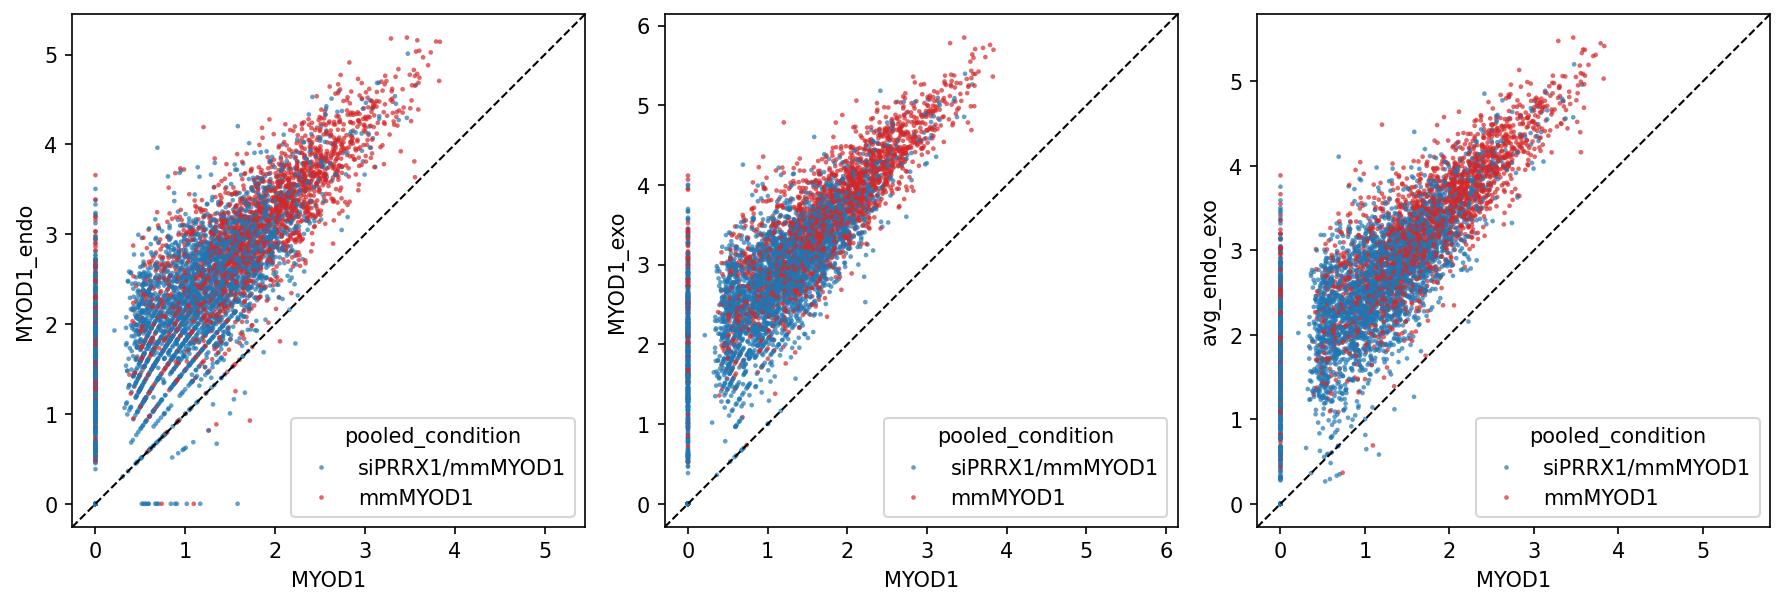

In [13]:
# genes = ['MYOD1_endo', 'MYOD1_exo']

conditions = ['mmMYOD1', 'siPRRX1/mmMYOD1']

tmp = df1[df1['pooled_condition'].isin(conditions)].copy()
tmp['pooled_condition'] = tmp['pooled_condition'].astype(str)

tmp['avg_endo_exo'] = (tmp['MYOD1_endo'] + tmp['MYOD1_exo']) / 2

genes = ['MYOD1_endo', 'MYOD1_exo', 'avg_endo_exo']


fig, axes = plt.subplots(1, 3, figsize=(12,4), dpi=150)

for i, gene in enumerate(genes):
    ax = axes[i]
    
    sns.scatterplot(
        data=tmp,
        x='MYOD1',
        y=gene,
        hue='pooled_condition',
        s=5,
        ec='none',
        alpha=0.7,
        palette=['tab:blue', 'tab:red'],
        ax=ax,
    )
    
    # get limits
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # use the same range for both axes
    low = min(xmin, ymin)
    high = max(xmax, ymax)

    # plot identity line
    ax.plot([low, high], [low, high], linestyle='--', color='black', linewidth=1)

    # (optional) enforce equal scaling so the line is truly 45°
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    ax.set_aspect('equal', adjustable='box')
    
plt.tight_layout()
plt.show()

# Load cell cycle genes

In [3]:
### --------- load cell cycle genes ---------

# regev
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
print(len(regev_genes))

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

regev_genes = [g for g in regev_genes if g in adata.var_names]
print(len(regev_genes))


# GO
cdf = pd.read_csv("../../resources/human_cell_cycle_genes.csv")
cc_genes = cdf['gene_name'].unique()
print(len(cc_genes))
cc_genes = [g for g in cc_genes if g in adata.var_names]
print(len(cc_genes))

97
94
142
120


In [4]:
all_cc_genes = list(set(regev_genes) | set(cc_genes))
print(len(all_cc_genes))

210


In [5]:
### --------- load cell cycle genes ---------

# regev
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
print(f'Total regev genes: {len(regev_genes)}')


# GO
cdf = pd.read_csv("../../resources/human_cell_cycle_genes.csv")
cc_genes = cdf['gene_name'].unique()
print(f'\nTotal GO cell cycle genes: {len(cc_genes)}')


# KEGG (hsa04110) -- downloaded from GSEA website
kdf = pd.read_json("../../resources/KEGG_CELL_CYCLE.v2026.1.Hs.json")
kegg_genes = kdf.loc['geneSymbols', 'KEGG_CELL_CYCLE']
print(f'\nTotal KEGG cell cycle genes: {len(kegg_genes)}')


### combine into single list
all_cc_genes = list(set(regev_genes) | set(cc_genes) | set(kegg_genes))
print(f'\nGenes in combined list: {len(all_cc_genes)}')

Total regev genes: 97

Total GO cell cycle genes: 142

Total KEGG cell cycle genes: 125

Genes in combined list: 321


In [6]:
all_cc_genes = [g for g in all_cc_genes if g in adata.var_names]
print(len(all_cc_genes))

293


# Bin cells by MYOD1 expression

In [7]:
### 
# group cells by HIGH / LOW MYOD1 expression
pdf = df1.copy()

pdf['avg_MYOD1'] = (pdf['MYOD1_exo'] + pdf['MYOD1_endo']) / 2


print("Total MYOD1 expression:")
print(f"Mean = {pdf['avg_MYOD1'].mean():.4f}, Median = {pdf['avg_MYOD1'].median()}\n")

print("Among positive MYOD1 expression:")
print(f"Mean = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].mean():.4f}, Median = {pdf[pdf['avg_MYOD1'] > 0]['avg_MYOD1'].median():.4f}\n")


# exp_bins = ['NE', 'low', 'med', 'high']


# pdf["exp_level"] = "NE"


cond_col = "pooled_condition" 
labels = ["low", "med", "high"]

pdf["exp_level"] = "NE"

pos_mask = pdf["avg_MYOD1"] > 0


def assign_tertiles_within_group(s):
    # s is avg_MYOD1 for positive cells in ONE condition
    if s.nunique() < 2:
        # not enough unique values to form quantiles reliably
        return pd.Series(["med"] * len(s), index=s.index)

    # Use rank to break ties deterministically so qcut can make equal counts
    r = s.rank(method="first")
    out = pd.qcut(r, q=3, labels=labels)
    return out.astype(str)

pdf.loc[pos_mask, "exp_level"] = (
    pdf.loc[pos_mask]
       .groupby(cond_col)["avg_MYOD1"]
       .apply(assign_tertiles_within_group)
       .reset_index(level=0, drop=True)
)

# checks: equal-sized tertiles per condition among positives
print(pdf.loc[pos_mask].groupby(cond_col)["exp_level"].value_counts())


# # Only use positively expressing cells to define equal-sized bins (quantiles)
# pos_mask = pdf["avg_MYOD1"] > 0
# pos = pdf.loc[pos_mask, "avg_MYOD1"]

# # 3 bins => tertiles among positives
# # duplicates="drop" avoids errors if there aren’t enough unique values
# qbin = pd.qcut(pos, q=3, labels=exp_bins[1:], duplicates="drop")

# pdf.loc[pos_mask, "exp_level"] = qbin.astype(str)


# # Quick checks
# print(pdf["exp_level"].value_counts(dropna=False))
# print("\nPositive-only counts:")
# print(pdf.loc[pos_mask, "exp_level"].value_counts())
# print("\nBin edges used (positives only):")
# print(pd.qcut(pos, q=3, retbins=True, duplicates="drop")[1])


# pdf.head()

# plt.figure(figsize=(5, 5), dpi=150)

# sns.scatterplot(
#     data=pdf,
#     x='MYOD1_exo',
#     y='MYOD1_endo',
#     hue='exp_level',
# )

# plt.show()

Total MYOD1 expression:
Mean = 1.0107, Median = 0.0

Among positive MYOD1 expression:
Mean = 2.5790, Median = 2.6923

pooled_condition  exp_level
Control           high            0
                  low             0
                  med             0
mmMYOD1           high          749
                  low           748
                  med           748
siPRRX1           high          260
                  low           260
                  med           259
siPRRX1/mmMYOD1   high         1121
                  low          1121
                  med          1120
Name: count, dtype: int64


/tmp/ipykernel_1396801/470050725.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cond_col)["avg_MYOD1"]
/tmp/ipykernel_1396801/470050725.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(pdf.loc[pos_mask].groupby(cond_col)["exp_level"].value_counts())


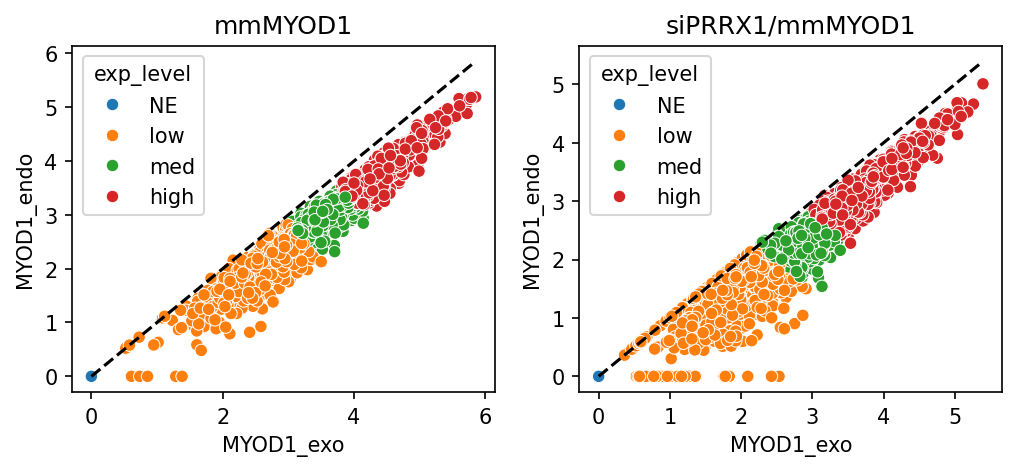

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=150)
axes = axes.flatten()

conds_to_plot = ['mmMYOD1', 'siPRRX1/mmMYOD1']

for i, cond in enumerate(conds_to_plot):
    ax = axes[i]
    
    tmp = pdf[pdf['pooled_condition'] == cond].copy()
    
    sns.scatterplot(
        tmp,
        x='MYOD1_exo',
        y='MYOD1_endo',
        hue='exp_level',
        hue_order=['NE', 'low', 'med', 'high'],
        ax=ax,
    )
    
    ax.set_title(f'{cond}')
    
    # Identity line
    min_val = min(tmp['MYOD1_exo'].min(), tmp['MYOD1_endo'].min())
    max_val = max(tmp['MYOD1_exo'].max(), tmp['MYOD1_endo'].max())
    
    ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='black')
    
    
plt.show()

In [8]:
adata

AnnData object with n_obs × n_vars = 16296 × 25128
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

# DGE

In [9]:
# add exp_level to adata.obs

# make a Series indexed by cell_id
s = (pdf.set_index("cell_id")["exp_level"])

# align to adata.obs_names and add
adata.obs["exp_level"] = s.reindex(adata.obs_names)

# (optional) keep ordered categorical + desired order
exp_bins = ["NE", "low", "med", "high"]
adata.obs["exp_level"] = pd.Categorical(adata.obs["exp_level"],
                                        categories=exp_bins,
                                        ordered=True)

# quick sanity checks
print(adata.obs["exp_level"].isna().sum(), "cells missing exp_level (no match in pdf)")
print(adata.obs["exp_level"].value_counts(dropna=False))

0 cells missing exp_level (no match in pdf)
exp_level
NE      9910
high    2130
low     2129
med     2127
Name: count, dtype: int64


In [10]:
### make grouping col that includes Control

adata.obs["exp_level_group"] = np.where(
    adata.obs["pooled_condition"].eq("Control"),
    "Control",
    adata.obs["pooled_condition"].astype(str) + "_" + adata.obs["exp_level"].astype(str)
)

adata.obs["exp_level_group"].value_counts()

exp_level_group
Control                 6902
siPRRX1_NE              2904
siPRRX1/mmMYOD1_high    1121
siPRRX1/mmMYOD1_low     1121
siPRRX1/mmMYOD1_med     1120
mmMYOD1_high             749
mmMYOD1_med              748
mmMYOD1_low              748
siPRRX1_high             260
siPRRX1_low              260
siPRRX1_med              259
siPRRX1/mmMYOD1_NE        94
mmMYOD1_NE                10
Name: count, dtype: int64

In [11]:
# # dge
sc.tl.rank_genes_groups(
    adata,
    groupby='exp_level_group',
    groups=['mmMYOD1_high', 'mmMYOD1_low', 'mmMYOD1_med'],
    reference='Control',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='myod_vs_ctrl',
)

sc.tl.rank_genes_groups(
    adata,
    groupby='exp_level_group',
    groups=['siPRRX1/mmMYOD1_high', 'siPRRX1/mmMYOD1_low', 'siPRRX1/mmMYOD1_med'],
    reference='Control',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='hyb_vs_ctrl',
)

ranking genes


... storing 'exp_level_group' as categorical


    finished (0:00:59)
ranking genes
    finished (0:00:55)


In [138]:
# in HIGH group
deg_key = 'myod_vs_ctrl'
# deg_key = 'hyb_vs_ctrl'

deg = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key=deg_key,
)

print(deg.shape)
deg.head()

(75384, 7)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,mmMYOD1_high,MYOD1_exo,45.019588,36.249886,0.0,0.0,1.000000
1,mmMYOD1_high,MYOD1_endo,45.019588,35.368896,0.0,0.0,1.000000
2,mmMYOD1_high,MYOD1,44.899376,33.251419,0.0,0.0,0.997330
3,mmMYOD1_high,MT-ND4,44.896973,3.106098,0.0,0.0,0.998665
4,mmMYOD1_high,TAF1D,39.262009,3.031776,0.0,0.0,0.961282


In [137]:
deg[deg['names'].isin(all_cc_genes)]['names'].nunique()

210

In [74]:
sig = deg[deg['pvals_adj'] < 0.05].copy()

sig = sig[sig['names'].isin(all_cc_genes)]

print(f"N genes: {sig['names'].nunique()}\n")

sig['direction'] = np.where(sig['logfoldchanges'] > 0, 'up', 'down')

print(sig.shape)
sig.head()

N genes: 167

(395, 8)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,direction
120,mmMYOD1_high,PLK2,21.904980,3.366909,2.328889e-106,1.121079e-104,0.604806,up
201,mmMYOD1_high,GMNN,18.982632,1.345906,2.374003e-80,8.228129e-79,0.781041,up
248,mmMYOD1_high,MYC,17.384644,2.604367,1.078565e-67,3.203568e-66,0.527370,up
252,mmMYOD1_high,NES,17.330755,1.933927,2.756865e-67,8.121278e-66,0.592790,up
393,mmMYOD1_high,FBXL7,14.825146,1.099218,1.007609e-49,2.164034e-48,0.724967,up


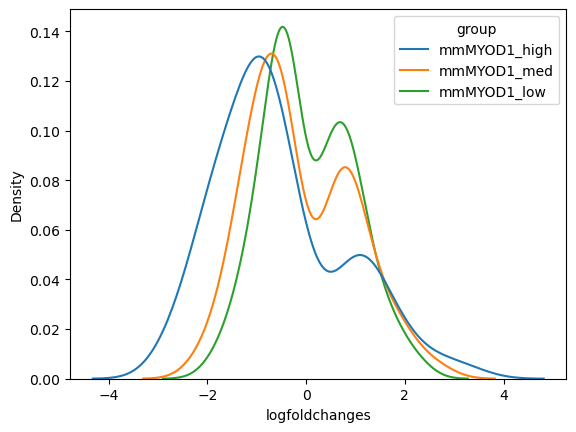

In [76]:
# group_key = 'siPRRX1/mmMYOD1'
group_key = 'mmMYOD1'

hue_order = [f'{group_key}_high', f'{group_key}_med', f'{group_key}_low']

sns.kdeplot(
    sig,
    x='logfoldchanges',
    hue='group',
    hue_order=hue_order,
)

plt.show()

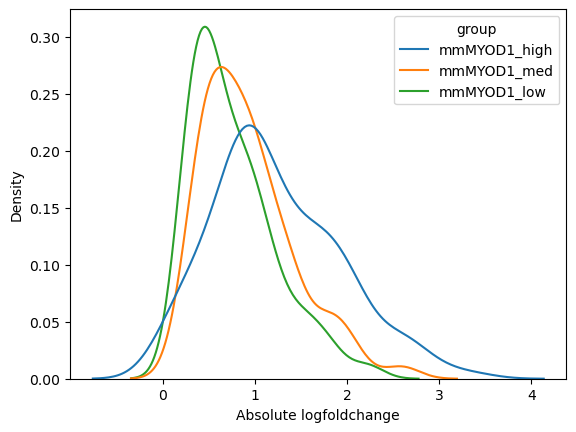

In [78]:
sig['abs_lfc'] = sig['logfoldchanges'].apply(abs)
sig.head()

sns.kdeplot(
    sig,
    x='abs_lfc',
    hue='group',
    hue_order=hue_order,
)

plt.xlabel("Absolute logfoldchange")

plt.show()

In [79]:
display(sig.groupby('group')['abs_lfc'].describe())
sig.groupby('group')['abs_lfc'].median()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
mmMYOD1_high,145.0,1.229831,0.691004,0.010781,0.765411,1.078613,1.702433,3.366909
mmMYOD1_low,123.0,0.760208,0.454168,0.181224,0.411186,0.644329,0.992125,2.255367
mmMYOD1_med,127.0,0.926728,0.498708,0.225691,0.540076,0.842801,1.179878,2.624249


group
mmMYOD1_high    1.078613
mmMYOD1_low     0.644329
mmMYOD1_med     0.842801
Name: abs_lfc, dtype: float64

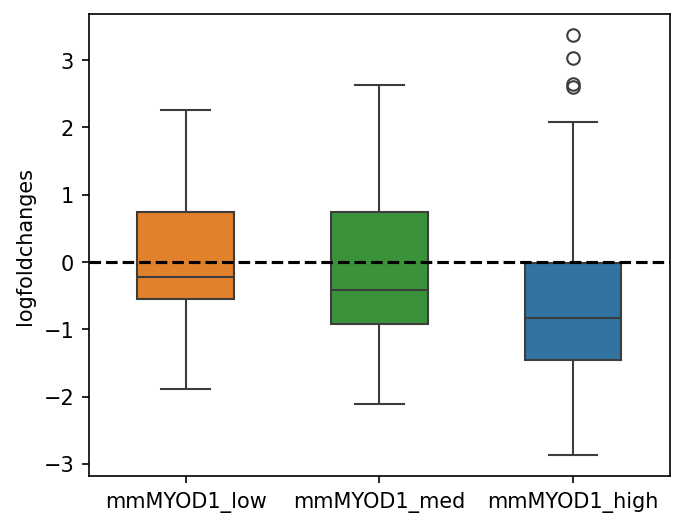

In [80]:
plt.figure(figsize=(5, 4), dpi=150)

sns.boxplot(
    sig,
    x='group',
    y='logfoldchanges',
    # y='abs_lfc',
    hue='group',
    order=[f'{group_key}_low', f'{group_key}_med', f'{group_key}_high'],
    width=0.5,
)

plt.axhline(y=0, ls='--', color='k')

plt.xlabel("")
# plt.ylabel("Absolute logfoldchange")

plt.show()

In [81]:
sig.groupby('group')['direction'].value_counts()

group         direction
mmMYOD1_high  down         110
              up            35
mmMYOD1_low   down          67
              up            56
mmMYOD1_med   down          77
              up            50
Name: count, dtype: int64

In [82]:
sig.groupby('group')['names'].nunique()

group
mmMYOD1_high    145
mmMYOD1_low     123
mmMYOD1_med     127
Name: names, dtype: int64

In [83]:
# groups_keep = ["mmMYOD1_low", "mmMYOD1_med", "mmMYOD1_high"]
groups_keep = [f'{group_key}_low', f'{group_key}_med', f'{group_key}_high']

direction = 'down'

tmp = sig[sig['direction'] == direction].copy()


wdf = (
    tmp.loc[tmp["group"].isin(groups_keep), ["names", "group", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "group"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="group", values="logfoldchanges")
      .rename(columns={
          f'{group_key}_low':  "logFC_low",
          f'{group_key}_med':  "logFC_med",
          f'{group_key}_high': "logFC_high",
      })
)

# # optional: keep only genes present in all three groups
# wide_all3 = wdf.dropna(subset=["logFC_low", "logFC_med", "logFC_high"])
# print(wide_all3.shape)

if direction == 'down':
    wdf = wdf.abs()

print(wdf.shape)
wdf.head()

(110, 3)


group,logFC_high,logFC_low,logFC_med
names,,,
ANLN,1.438762,0.475400,0.970143
ANP32E,1.669879,0.344214,0.816024
APP,2.585188,1.881886,2.103895
ARPP19,0.270193,0.201679,NaN
ATAD2,0.700056,NaN,NaN


In [ ]:
# how many sig in one group



(33, 4)


group,logFC_high,logFC_low,logFC_med,delta_high_low
names,,,,
APP,2.020869,1.690596,1.742139,0.330273
BCAT1,0.383386,0.333560,0.401849,0.049826
CALM2,0.662872,0.360216,0.419185,0.302656
CALM3,0.870304,0.351717,0.443061,0.518587
CBX5,0.701829,0.233360,0.338254,0.468469


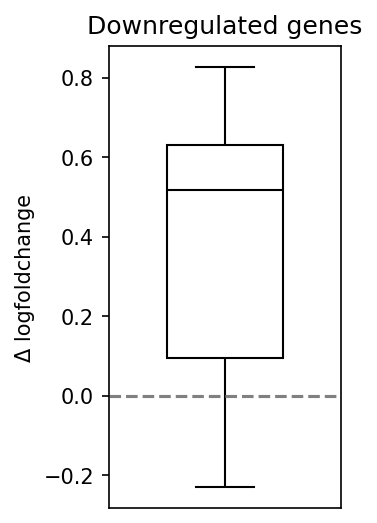

In [158]:
wdf1 = wdf.dropna(subset=['logFC_low', 'logFC_high']).copy()
wdf1['delta_high_low'] = wdf1['logFC_high'] - wdf1['logFC_low']

print(wdf1.shape)
display(wdf1.head())

plt.figure(figsize=(2, 4), dpi=150)

sns.boxplot(
    wdf1,
    y='delta_high_low',
    width=0.5,
    color='white',
    linecolor='k',
    # showfliers=False,
)

plt.ylabel("Δ logfoldchange")
plt.gca().tick_params(axis='x', bottom=False)

plt.axhline(y=0, ls='--', color='gray')

if direction == 'up':
    plt.title("Upregulated genes")
    
if direction == 'down':
    plt.title("Downregulated genes")
    
plt.show()

In [159]:
display(wdf1.sort_values(by='delta_high_low', ascending=False).head())
display(wdf1.sort_values(by='delta_high_low', ascending=True).head())

group,logFC_high,logFC_low,logFC_med,delta_high_low
names,,,,
DLGAP5,1.119850,0.293020,0.519974,0.826830
TOP2A,1.494931,0.670144,0.908652,0.824786
NUSAP1,1.054829,0.238878,0.390685,0.815952
TTK,1.193748,0.393467,0.581728,0.800280
ITGB1,1.827535,1.032171,1.194961,0.795364


group,logFC_high,logFC_low,logFC_med,delta_high_low
names,,,,
WEE1,0.445689,0.674995,0.576163,-0.229306
PBX1,1.280786,1.408344,1.266965,-0.127558
CENPA,1.766082,1.831966,1.745424,-0.065884
USP22,0.396927,0.430029,0.631913,-0.033102
CKS2,0.247252,0.226537,0.242476,0.020715


In [84]:
groups_keep = [f'{group_key}_low', f'{group_key}_high']

kdf = sig[sig['group'].isin(groups_keep)].copy()
print(kdf.shape)


# Step 1: build a per-gene summary of directions across groups
gene_summary = (
    kdf.groupby('names')
      .agg(
          n_groups=('group', 'nunique'),
          n_directions=('direction', lambda x: x.nunique()),
          direction_set=('direction', lambda x: set(x))
      )
      .reset_index()
)

# Step 2: define logic for consistency
def classify(row):
    if row['n_groups'] == 1:
        return 'unique_to_group'
    elif row['n_directions'] == 1:
        return 'match'
    else:
        return 'mismatch'

gene_summary['direction_consistency'] = gene_summary.apply(classify, axis=1)

# Step 3: map back to original dataframe
kdf = kdf.merge(
    gene_summary[['names', 'direction_consistency']],
    on='names',
    how='left'
)

kdf.head()

(268, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,direction,abs_lfc,direction_consistency
0,mmMYOD1_high,PLK2,21.904980,3.366909,2.328889e-106,1.121079e-104,0.604806,up,3.366909,match
1,mmMYOD1_high,GMNN,18.982632,1.345906,2.374003e-80,8.228129e-79,0.781041,up,1.345906,match
2,mmMYOD1_high,MYC,17.384644,2.604367,1.078565e-67,3.203568e-66,0.527370,up,2.604367,match
3,mmMYOD1_high,NES,17.330755,1.933927,2.756865e-67,8.121278e-66,0.592790,up,1.933927,match
4,mmMYOD1_high,FBXL7,14.825146,1.099218,1.007609e-49,2.164034e-48,0.724967,up,1.099218,match


In [85]:
print(kdf['names'].nunique())

print("\n", kdf.groupby('group')['names'].nunique())

print("\n", kdf.groupby(['group', 'direction'])['names'].nunique())

164

 group
mmMYOD1_high    145
mmMYOD1_low     123
Name: names, dtype: int64

 group         direction
mmMYOD1_high  down         110
              up            35
mmMYOD1_low   down          67
              up            56
Name: names, dtype: int64


In [86]:
print(kdf.groupby('group')['direction_consistency'].value_counts())

group         direction_consistency
mmMYOD1_high  match                    95
              unique_to_group          41
              mismatch                  9
mmMYOD1_low   match                    95
              unique_to_group          19
              mismatch                  9
Name: count, dtype: int64


In [92]:
mdf = kdf[kdf['direction_consistency'] == 'mismatch'].copy()

mdf.head()

mdf = mdf.pivot(index='names', columns='group', values="logfoldchanges")
mdf.index.name = None
mdf.columns.name = None
display(mdf.head(10))

,mmMYOD1_high,mmMYOD1_low
CHEK1,-0.695080,0.274394
CUL2,-0.127053,0.392794
DTL,-0.093315,0.667908
FBXO7,-0.200738,0.468378
GINS2,-0.558920,0.470706
HSPA8,-1.425480,0.303626
MCM4,-0.560523,0.532062
PCNA,-0.739672,0.414214
POLD3,-0.446083,0.282473


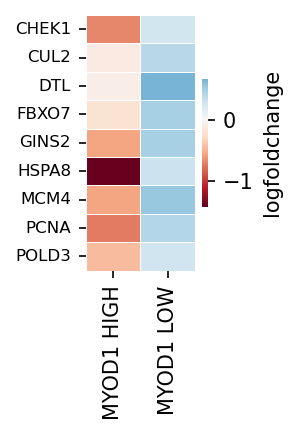

In [90]:
vmin = (mdf.min()).min()
vmax = (mdf.max()).max()

plt.figure(figsize=(2, 3), dpi=150)#max(6, 0.25 * len(mat))))  # scale height with #genes
ax = sns.heatmap(
    mdf,
    # cmap=custom_cmap,
    cmap="RdBu",
    linewidths=0.35,
    linecolor="white",
    cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    vmin=vmin,
    vmax=vmax,
    center=0,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(["MYOD1 HIGH", "MYOD1 LOW"], rotation=90)

ax.set_yticks([i + 0.5 for i in range(len(mdf))])
ax.set_yticklabels(mdf.index.to_list(), fontsize=8, va='center')


plt.tight_layout()
plt.show()

In [165]:
# groups_keep = ["mmMYOD1_low", "mmMYOD1_high"]

direction = 'up'

tmp = sig[sig['direction'] == direction].copy()


wdf = (
    tmp.loc[tmp["group"].isin(groups_keep), ["names", "group", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "group"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="group", values="logfoldchanges")
      .rename(columns={
          f'{group_key}_low':  "logFC_low",
          f'{group_key}_med':  "logFC_med",
          f'{group_key}_high': "logFC_high",
      })
)

# # optional: keep only genes present in all three groups
# wide_all3 = wdf.dropna(subset=["logFC_low", "logFC_med", "logFC_high"])
# print(wide_all3.shape)

if direction == 'down':
    wdf = wdf.abs()

print(wdf.shape)
wdf.head()

wdf1 = wdf.dropna(subset=['logFC_low', 'logFC_high']).copy()

print(wdf1.shape)

wdf1['delta_high_low'] = wdf1['logFC_high'] - wdf1['logFC_low']

wdf1['pos_delta'] = wdf1['delta_high_low'] > 0

print(wdf1['pos_delta'].value_counts(normalize=True))
wdf1.head()

(85, 2)
(32, 2)
pos_delta
True     0.5625
False    0.4375
Name: proportion, dtype: float64


group,logFC_high,logFC_low,delta_high_low,pos_delta
names,,,,
AMBRA1,0.299395,0.311337,-0.011942,False
BRIP1,1.132953,1.357508,-0.224555,False
BTN2A2,2.242478,1.725158,0.517320,True
CASP8AP2,0.570847,0.945060,-0.374213,False
CCND1,0.699680,0.884521,-0.184841,False


# DGE (by phase group)

In [11]:
# Create a collapsed phase column
adata.obs['phase_grouped'] = adata.obs['phase'].replace({
    'G1': 'G1S',
    'S': 'G1S',
    'G2M': 'G2M'
})

# Create the combined grouping column
adata.obs['exp_phase_group'] = (
    adata.obs['exp_level_group'].astype(str) + '_' +
    adata.obs['phase_grouped'].astype(str)
)

adata.obs["exp_phase_group"].value_counts(sort=False)

/tmp/ipykernel_1396801/35519897.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs['phase_grouped'] = adata.obs['phase'].replace({


exp_phase_group
siPRRX1/mmMYOD1_high_G2M     190
mmMYOD1_med_G1S              635
siPRRX1/mmMYOD1_med_G1S      842
siPRRX1_NE_G2M              1179
mmMYOD1_low_G2M              133
siPRRX1_NE_G1S              1725
siPRRX1/mmMYOD1_low_G1S      808
siPRRX1_med_G1S              157
siPRRX1_high_G1S             161
siPRRX1/mmMYOD1_med_G2M      278
mmMYOD1_high_G1S             665
siPRRX1_low_G1S              155
siPRRX1/mmMYOD1_high_G1S     931
mmMYOD1_low_G1S              615
mmMYOD1_med_G2M              113
siPRRX1/mmMYOD1_low_G2M      313
mmMYOD1_high_G2M              84
mmMYOD1_NE_G1S                 9
siPRRX1_high_G2M              99
siPRRX1/mmMYOD1_NE_G1S        57
siPRRX1_med_G2M              102
siPRRX1_low_G2M              105
siPRRX1/mmMYOD1_NE_G2M        37
mmMYOD1_NE_G2M                 1
Control_G2M                 2980
Control_G1S                 3922
Name: count, dtype: int64

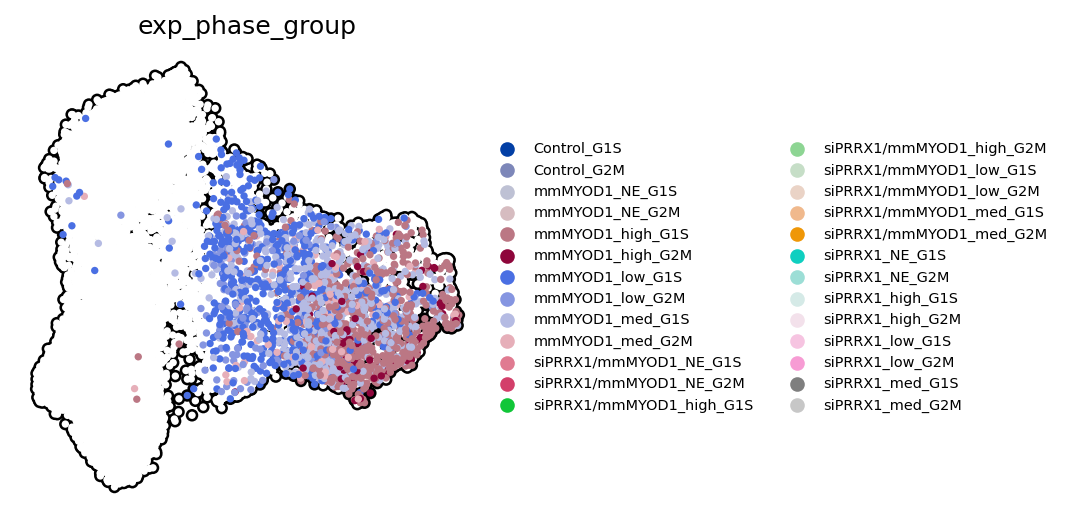

In [14]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4


group = 'mmMYOD1'
conds = [f'{group}_low_G1S', f'{group}_med_G1S', f'{group}_high_G1S',
         f'{group}_low_G2M', f'{group}_med_G2M', f'{group}_high_G2M'
        ]


mask = adata.obs['exp_phase_group'].isin(conds)


sc.pl.umap(
    adata, 
    color='exp_phase_group',
    mask_obs=mask,
    size=50,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    na_in_legend=False,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.25,
    na_color='white',
    legend_fontsize='x-small',
)

In [20]:
groups = adata.obs[['exp_phase_group']].copy()
groups = groups.reset_index(names='cell_id')
print(groups.shape)

tmp = pd.merge(df1, groups, how='left', on='cell_id')

tmp['exp_level'] = tmp['exp_phase_group'].str.split('_').str[-2].str.upper()
tmp['phase_group'] = tmp['exp_phase_group'].str.split('_').str[-1].str.upper()

print(tmp.shape)
tmp.head()

(16296, 2)
(16296, 9)


,cell_id,MYOD1_exo,MYOD1_endo,pooled_condition,leiden_split,phase,exp_phase_group,exp_level,phase_group
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,siPRRX1/mmMYOD1,H1,G2M,siPRRX1/mmMYOD1_high_G2M,HIGH,G2M
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,mmMYOD1,M1,S,mmMYOD1_med_G1S,MED,G1S
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,siPRRX1/mmMYOD1,H1,G1,siPRRX1/mmMYOD1_med_G1S,MED,G1S
3,AAACCATTCACGTAAT_hybrid,0.000000,0.000000,siPRRX1,P1,G2M,siPRRX1_NE_G2M,NE,G2M
4,AAACCATTCAGGCAGA_hybrid,0.000000,0.000000,siPRRX1,P1,G2M,siPRRX1_NE_G2M,NE,G2M


mmMYOD1 G1S: 1924
siPRRX1/mmMYOD1 G1S: 2638


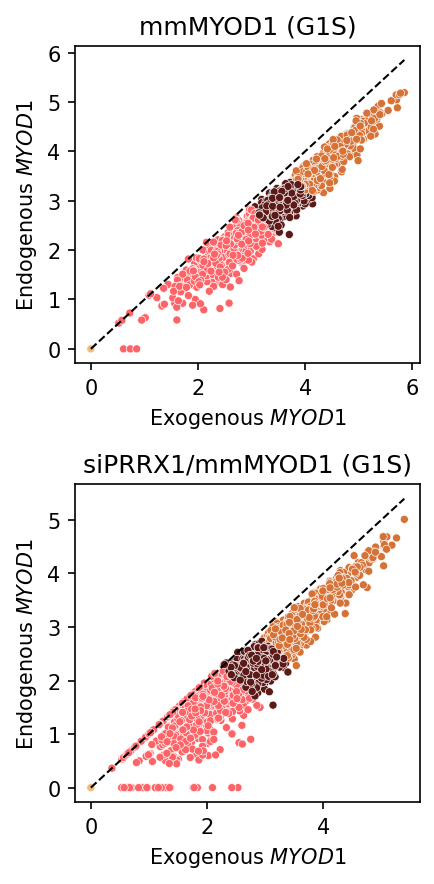

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(3, 6), dpi=150)
axes = axes.flatten()

conds_to_plot = ['mmMYOD1', 'siPRRX1/mmMYOD1']
phase = 'G1S'

palette = [
    '#F1BB7B',
    '#FD6467',
    '#5B1A18',
    '#D67236',
]

for i, cond in enumerate(conds_to_plot):
    ax = axes[i]
    
    tmp1 = tmp[(tmp['pooled_condition'] == cond) & (tmp['phase_group'] == phase)].copy()
    print(f'{cond} {phase}: {len(tmp1)}')
    
    sns.scatterplot(
        tmp1,
        x='MYOD1_exo',
        y='MYOD1_endo',
        hue='exp_level',
        hue_order=['NE', 'LOW', 'MED', 'HIGH'],
        palette=palette,
        s=15,
        ax=ax,
        legend=False,
    )
    
    ax.set_title(f'{cond} ({phase})')
    ax.set_ylabel('Endogenous $MYOD1$')
    ax.set_xlabel('Exogenous $MYOD1$')
    
    # Identity line
    min_val = min(tmp1['MYOD1_exo'].min(), tmp1['MYOD1_endo'].min())
    max_val = max(tmp1['MYOD1_exo'].max(), tmp1['MYOD1_endo'].max())
    
    ax.plot([min_val, max_val], [min_val, max_val], ls='--', color='black', lw=1)
    

plt.tight_layout()
plt.show()

In [16]:
# G1S

phase = 'G1S'

groups = [f'mmMYOD1_high_{phase}', f'mmMYOD1_low_{phase}', f'mmMYOD1_med_{phase}']

tmp = adata.obs[adata.obs['exp_phase_group'].isin(groups)]
print(tmp['exp_phase_group'].value_counts())

sc.tl.rank_genes_groups(
    adata,
    groupby='exp_phase_group',
    groups=groups,
    reference=f'Control_{phase}',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='myod_vs_ctrl_g1s',
)

exp_phase_group
mmMYOD1_high_G1S    665
mmMYOD1_med_G1S     635
mmMYOD1_low_G1S     615
Name: count, dtype: int64
ranking genes


... storing 'exp_phase_group' as categorical


    finished (0:00:26)


In [143]:
# in HIGH group
deg_key = 'myod_vs_ctrl_g1s'

deg = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key=deg_key,
)

deg['reference_group'] = 'Control_G1S'
deg['direction'] = np.where(deg['logfoldchanges'] > 0, 'up', 'down')

print(deg.shape)
deg.head()

(75384, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,mmMYOD1_high_G1S,MYOD1_exo,41.296528,36.265495,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
1,mmMYOD1_high_G1S,MYOD1_endo,41.296528,35.380703,0.000000e+00,0.000000e+00,1.000000,Control_G1S,up
2,mmMYOD1_high_G1S,MYOD1,41.172329,33.265804,0.000000e+00,0.000000e+00,0.996992,Control_G1S,up
3,mmMYOD1_high_G1S,MT-ND4,41.169952,3.180320,0.000000e+00,0.000000e+00,0.998496,Control_G1S,up
4,mmMYOD1_high_G1S,LINC-PINT,36.189045,3.098549,9.053250e-287,3.296958e-284,0.962406,Control_G1S,up


In [150]:
sig = deg[deg['pvals_adj'] < 0.05].copy()
print(sig.shape)
sig.head()

# # write out
# sig.to_csv("../../tables/DEGs_MyodExpLevels_mmMYOD1_G1S.csv", index=False)


sig = sig[sig['names'].isin(all_cc_genes)]

print(f"N genes: {sig['names'].nunique()}\n")

sig['direction'] = np.where(sig['logfoldchanges'] > 0, 'up', 'down')

print(sig.shape)
sig.head()

(21850, 9)
N genes: 162

(405, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
19,siPRRX1/mmMYOD1_high_G1S,GMNN,30.881842,2.588793,2.094333e-209,3.898252e-207,0.841031,Control_G1S,up
168,siPRRX1/mmMYOD1_high_G1S,PLK2,18.937969,2.928978,5.549692e-80,3.051481e-78,0.545650,Control_G1S,up
231,siPRRX1/mmMYOD1_high_G1S,FBXL7,17.425318,1.163699,5.301234e-68,2.332914e-66,0.789474,Control_G1S,up
324,siPRRX1/mmMYOD1_high_G1S,CDKN1A,15.276446,1.320675,1.097657e-52,3.742460e-51,0.722879,Control_G1S,up
357,siPRRX1/mmMYOD1_high_G1S,BRIP1,14.790622,1.593779,1.683921e-49,5.342623e-48,0.544576,Control_G1S,up


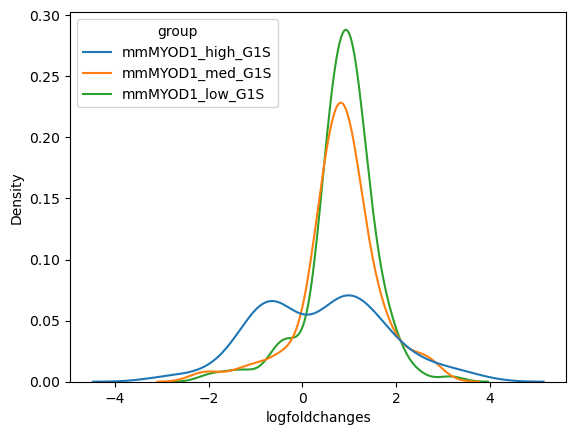

In [117]:
group_key = 'mmMYOD1'
hue_order=[f'{group_key}_high_G1S', f'{group_key}_med_G1S', f'{group_key}_low_G1S']

sns.kdeplot(
    sig,
    x='logfoldchanges',
    hue='group',
    hue_order=hue_order,
)

plt.show()

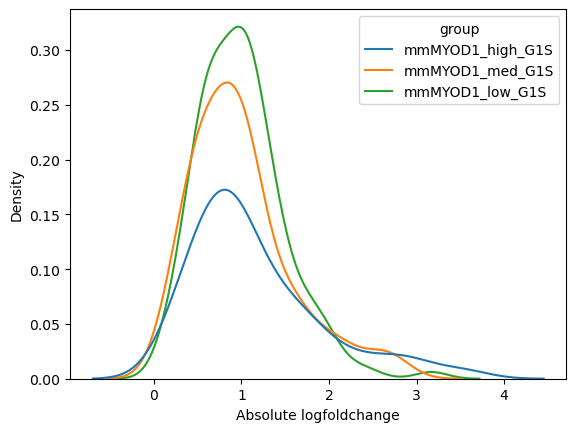

In [118]:
sig['abs_lfc'] = sig['logfoldchanges'].apply(abs)
sig.head()

sns.kdeplot(
    sig,
    x='abs_lfc',
    hue='group',
    hue_order=hue_order,
)

plt.xlabel("Absolute logfoldchange")

plt.show()

In [119]:
display(sig.groupby('group')['abs_lfc'].describe())
sig.groupby('group')['abs_lfc'].median()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
mmMYOD1_high_G1S,92.0,1.158601,0.747621,0.210495,0.666449,0.936282,1.491550,3.543855
mmMYOD1_low_G1S,139.0,0.997706,0.491725,0.130383,0.641242,0.958756,1.263693,3.167902
mmMYOD1_med_G1S,124.0,0.996275,0.582285,0.139016,0.557014,0.887403,1.188298,2.827006


group
mmMYOD1_high_G1S    0.936282
mmMYOD1_low_G1S     0.958756
mmMYOD1_med_G1S     0.887403
Name: abs_lfc, dtype: float64

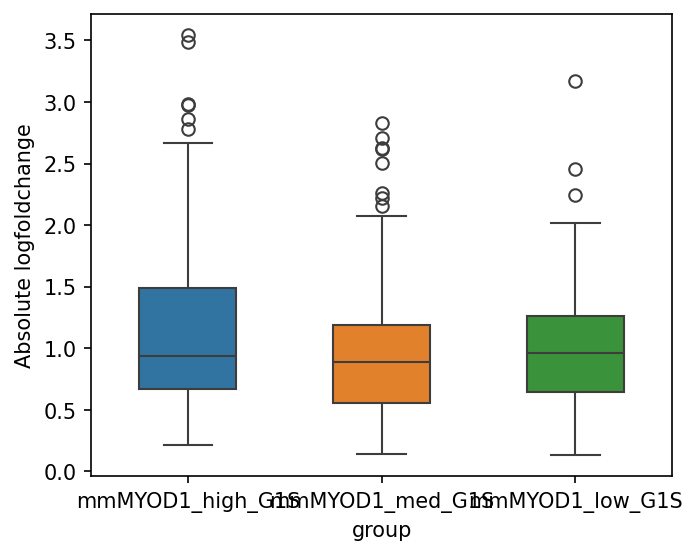

In [44]:
plt.figure(figsize=(5, 4), dpi=150)

sns.boxplot(
    sig,
    x='group',
    # y='logfoldchanges',
    y='abs_lfc',
    hue='group',
    order=hue_order,
    hue_order=hue_order,
    width=0.5,
)

# plt.axhline(y=0, ls='--', color='k')

# plt.xlabel("")
plt.ylabel("Absolute logfoldchange")

plt.show()

In [120]:
# groups_keep = ["mmMYOD1_low", "mmMYOD1_med", "mmMYOD1_high"]
groups_keep = [f'{group_key}_low_G1S', f'{group_key}_med_G1S', f'{group_key}_high_G1S']

direction = 'down'

tmp = sig[sig['direction'] == direction].copy()


wdf = (
    tmp.loc[tmp["group"].isin(groups_keep), ["names", "group", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "group"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="group", values="logfoldchanges")
      .rename(columns={
          f'{group_key}_low_G1S':  "logFC_low",
          f'{group_key}_med_G1S':  "logFC_med",
          f'{group_key}_high_G1S': "logFC_high",
      })
)

if direction == 'down':
    wdf = wdf.abs()

print(wdf.shape)
wdf.head()

(42, 3)


group,logFC_high,logFC_low,logFC_med
names,,,
ANP32E,0.606470,NaN,NaN
APP,2.664147,2.017786,2.156026
BCAT1,0.399278,0.442231,0.475882
BIRC5,0.588815,NaN,NaN
CALM1,0.801251,0.145498,0.294558


(12, 4)


group,logFC_high,logFC_low,logFC_med,delta_high_low
names,,,,
APP,2.664147,2.017786,2.156026,0.646361
BCAT1,0.399278,0.442231,0.475882,-0.042953
CALM1,0.801251,0.145498,0.294558,0.655753
CALM2,0.757849,0.130383,0.247112,0.627466
CALM3,1.892928,0.677959,1.138347,1.214969


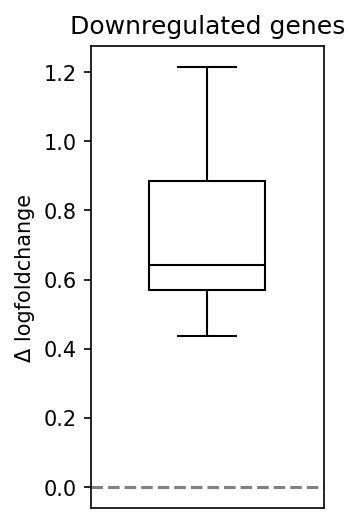

In [53]:
wdf1 = wdf.dropna(subset=['logFC_low', 'logFC_high']).copy()
wdf1['delta_high_low'] = wdf1['logFC_high'] - wdf1['logFC_low']

print(wdf1.shape)
display(wdf1.head())

plt.figure(figsize=(2, 4), dpi=150)

sns.boxplot(
    wdf1,
    y='delta_high_low',
    width=0.5,
    color='white',
    linecolor='k',
    showfliers=False,
)

plt.ylabel("Δ logfoldchange")
plt.gca().tick_params(axis='x', bottom=False)

plt.axhline(y=0, ls='--', color='gray')

if direction == 'up':
    plt.title("Upregulated genes")
    
if direction == 'down':
    plt.title("Downregulated genes")
    
plt.show()

In [52]:
display(wdf1.sort_values(by='delta_high_low', ascending=False).head())
display(wdf1.sort_values(by='delta_high_low', ascending=True).head())

group,logFC_high,logFC_low,logFC_med,delta_high_low
names,,,,
ITGB1,2.864909,1.342566,2.069905,1.522344
CALM3,1.892928,0.677959,1.138347,1.214969
RB1,1.523288,0.568271,0.994244,0.955017
RPS6,1.152640,0.288901,0.441620,0.863739
CALM1,0.801251,0.145498,0.294558,0.655753


group,logFC_high,logFC_low,logFC_med,delta_high_low
names,,,,
PBX1,1.615767,1.674736,1.593872,-0.058969
BCAT1,0.399278,0.442231,0.475882,-0.042953
CUL4B,0.940254,0.504841,0.669123,0.435413
CSDE1,0.782668,0.168310,0.414482,0.614358
CALM2,0.757849,0.130383,0.247112,0.627466


In [121]:
groups_keep = [f'{group_key}_low_G1S', f'{group_key}_high_G1S']

kdf = sig[sig['group'].isin(groups_keep)].copy()
print(kdf.shape)


# Step 1: build a per-gene summary of directions across groups
gene_summary = (
    kdf.groupby('names')
      .agg(
          n_groups=('group', 'nunique'),
          n_directions=('direction', lambda x: x.nunique()),
          direction_set=('direction', lambda x: set(x))
      )
      .reset_index()
)

# Step 2: define logic for consistency
def classify(row):
    if row['n_groups'] == 1:
        return 'unique_to_group'
    elif row['n_directions'] == 1:
        return 'match'
    else:
        return 'mismatch'

gene_summary['direction_consistency'] = gene_summary.apply(classify, axis=1)

# Step 3: map back to original dataframe
kdf = kdf.merge(
    gene_summary[['names', 'direction_consistency']],
    on='names',
    how='left'
)

kdf.head()

(231, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,direction,abs_lfc,direction_consistency
0,mmMYOD1_high_G1S,GMNN,23.052416,2.295428,1.391079e-117,9.874300e-116,0.769925,up,2.295428,match
1,mmMYOD1_high_G1S,PLK2,20.845648,3.490016,1.669341e-96,9.363212e-95,0.612030,up,3.490016,match
2,mmMYOD1_high_G1S,NES,18.075657,2.351126,4.956188e-73,1.939861e-71,0.592481,up,2.351126,match
3,mmMYOD1_high_G1S,MYC,17.782084,2.979373,9.729763e-71,3.738371e-69,0.538346,up,2.979373,match
4,mmMYOD1_high_G1S,FBXL7,13.908415,1.147300,5.631406e-44,1.333704e-42,0.718797,up,1.147300,match


In [122]:
print(kdf['names'].nunique())

print("\n", kdf.groupby('group')['names'].nunique())

print("\n", kdf.groupby(['group', 'direction'])['names'].nunique())

153

 group
mmMYOD1_high_G1S     92
mmMYOD1_low_G1S     139
Name: names, dtype: int64

 group             direction
mmMYOD1_high_G1S  down          40
                  up            52
mmMYOD1_low_G1S   down          14
                  up           125
Name: names, dtype: int64


In [123]:
print(kdf.groupby('group')['direction_consistency'].value_counts())

group             direction_consistency
mmMYOD1_high_G1S  match                    59
                  mismatch                 19
                  unique_to_group          14
mmMYOD1_low_G1S   unique_to_group          61
                  match                    59
                  mismatch                 19
Name: count, dtype: int64


In [124]:
mdf = kdf[kdf['direction_consistency'] == 'mismatch'].copy()

mdf.head()

mdf = mdf.pivot(index='names', columns='group', values="logfoldchanges")
mdf.index.name = None
mdf.columns.name = None
display(mdf)

,mmMYOD1_high_G1S,mmMYOD1_low_G1S
ANP32E,-0.606470,0.576757
BIRC5,-0.588815,1.081817
CBX5,-0.316281,0.278277
CHEK1,-0.212744,0.744650
CKS1B,-0.622493,0.556446
DLGAP5,-1.016875,0.756706
ECT2,-0.274038,0.702160
HSPA8,-1.157550,0.542897
KHDRBS1,-0.511001,0.330539
MCM5,-0.714668,0.563650


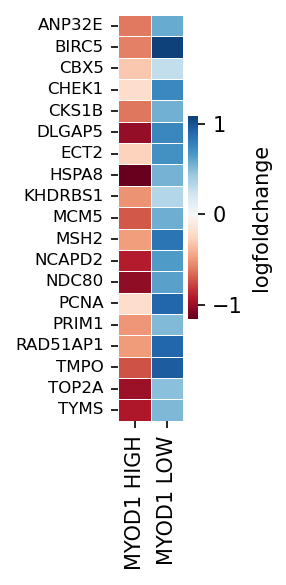

In [125]:
vmin = (mdf.min()).min()
vmax = (mdf.max()).max()

plt.figure(figsize=(2, 4), dpi=150)#max(6, 0.25 * len(mat))))  # scale height with #genes
ax = sns.heatmap(
    mdf,
    # cmap=custom_cmap,
    cmap="RdBu",
    linewidths=0.35,
    linecolor="white",
    cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    vmin=vmin,
    vmax=vmax,
    center=0,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(["MYOD1 HIGH", "MYOD1 LOW"], rotation=90)

ax.set_yticks([i + 0.5 for i in range(len(mdf))])
ax.set_yticklabels(mdf.index.to_list(), fontsize=8, va='center')


plt.tight_layout()
plt.show()

In [58]:
# groups_keep = ["mmMYOD1_low", "mmMYOD1_high"]

direction = 'down'

tmp = sig[sig['direction'] == direction].copy()


wdf = (
    tmp.loc[tmp["group"].isin(groups_keep), ["names", "group", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "group"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="group", values="logfoldchanges")
      .rename(columns={
          f'{group_key}_low_G1S':  "logFC_low",
          f'{group_key}_med_G1S':  "logFC_med",
          f'{group_key}_high_G1S': "logFC_high",
      })
)

# # optional: keep only genes present in all three groups
# wide_all3 = wdf.dropna(subset=["logFC_low", "logFC_med", "logFC_high"])
# print(wide_all3.shape)

if direction == 'down':
    wdf = wdf.abs()

print(wdf.shape)
wdf.head()

wdf1 = wdf.dropna(subset=['logFC_low', 'logFC_high']).copy()

print(wdf1.shape)

wdf1['delta_high_low'] = wdf1['logFC_high'] - wdf1['logFC_low']

wdf1['pos_delta'] = wdf1['delta_high_low'] > 0

print(wdf1['pos_delta'].value_counts(normalize=True))
wdf1.head()

(42, 2)
(12, 2)
pos_delta
True     0.833333
False    0.166667
Name: proportion, dtype: float64


group,logFC_high,logFC_low,delta_high_low,pos_delta
names,,,,
APP,2.664147,2.017786,0.646361,True
BCAT1,0.399278,0.442231,-0.042953,False
CALM1,0.801251,0.145498,0.655753,True
CALM2,0.757849,0.130383,0.627466,True
CALM3,1.892928,0.677959,1.214969,True


In [17]:
### HYB
phase = 'G1S'

groups = [f'siPRRX1/mmMYOD1_high_{phase}', f'siPRRX1/mmMYOD1_low_{phase}', f'siPRRX1/mmMYOD1_med_{phase}']

tmp = adata.obs[adata.obs['exp_phase_group'].isin(groups)]
print(tmp['exp_phase_group'].value_counts())

sc.tl.rank_genes_groups(
    adata,
    groupby='exp_phase_group',
    groups=groups,
    reference=f'Control_{phase}',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
    key_added='hyb_vs_ctrl_g1s',
)

exp_phase_group
siPRRX1/mmMYOD1_high_G1S    931
siPRRX1/mmMYOD1_med_G1S     842
siPRRX1/mmMYOD1_low_G1S     808
mmMYOD1_NE_G1S                0
mmMYOD1_high_G1S              0
mmMYOD1_high_G2M              0
mmMYOD1_low_G1S               0
mmMYOD1_NE_G2M                0
Control_G1S                   0
Control_G2M                   0
mmMYOD1_med_G2M               0
mmMYOD1_med_G1S               0
mmMYOD1_low_G2M               0
siPRRX1/mmMYOD1_NE_G1S        0
siPRRX1/mmMYOD1_high_G2M      0
siPRRX1/mmMYOD1_NE_G2M        0
siPRRX1/mmMYOD1_low_G2M       0
siPRRX1/mmMYOD1_med_G2M       0
siPRRX1_NE_G1S                0
siPRRX1_NE_G2M                0
siPRRX1_high_G1S              0
siPRRX1_high_G2M              0
siPRRX1_low_G1S               0
siPRRX1_low_G2M               0
siPRRX1_med_G1S               0
siPRRX1_med_G2M               0
Name: count, dtype: int64
ranking genes
    finished (0:00:27)


In [147]:
# in HIGH group
deg_key = 'hyb_vs_ctrl_g1s'

deg = sc.get.rank_genes_groups_df(
    adata,
    group=None,
    key=deg_key,
)

deg['reference_group'] = 'Control_G1S'
deg['direction'] = np.where(deg['logfoldchanges'] > 0, 'up', 'down')

print(deg.shape)
deg.head()

(75384, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,reference_group,direction
0,siPRRX1/mmMYOD1_high_G1S,MYOD1_exo,47.505005,35.085709,0.0,0.0,1.000000,Control_G1S,up
1,siPRRX1/mmMYOD1_high_G1S,MYOD1_endo,47.505005,34.325275,0.0,0.0,1.000000,Control_G1S,up
2,siPRRX1/mmMYOD1_high_G1S,MT-ND4,47.501183,2.978337,0.0,0.0,1.000000,Control_G1S,up
3,siPRRX1/mmMYOD1_high_G1S,MYOD1,46.688595,32.032375,0.0,0.0,0.982814,Control_G1S,up
4,siPRRX1/mmMYOD1_high_G1S,LINC-PINT,38.898235,2.623778,0.0,0.0,0.963480,Control_G1S,up


In [149]:
sig = deg[deg['pvals_adj'] < 0.05].copy()

print(sig.shape)
sig.head()

# # write out
# sig.to_csv("../../tables/DEGs_MyodExpLevels_HYB_G1S.csv", index=False)

sig = sig[sig['names'].isin(all_cc_genes)]

print(f"N genes: {sig['names'].nunique()}\n")

sig['direction'] = np.where(sig['logfoldchanges'] > 0, 'up', 'down')

print(sig.shape)
sig.head()

(21850, 9)


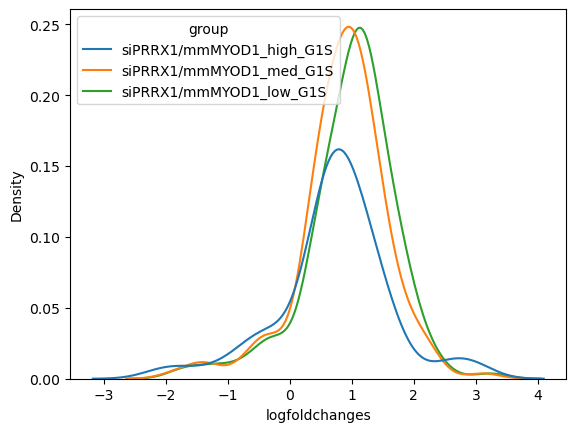

In [127]:
group_key = 'siPRRX1/mmMYOD1'
hue_order=[f'{group_key}_high_G1S', f'{group_key}_med_G1S', f'{group_key}_low_G1S']

sns.kdeplot(
    sig,
    x='logfoldchanges',
    hue='group',
    hue_order=hue_order,
)

plt.show()

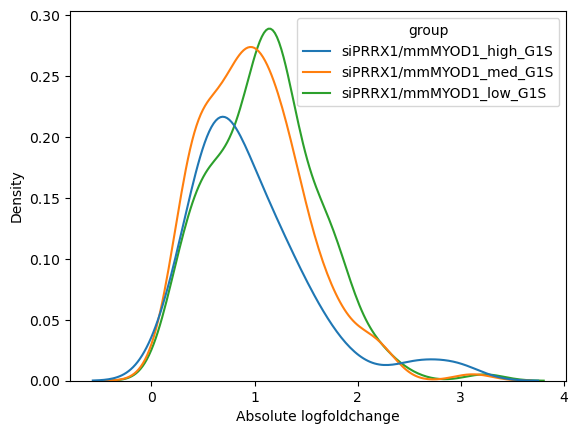

In [128]:
sig['abs_lfc'] = sig['logfoldchanges'].apply(abs)
sig.head()

sns.kdeplot(
    sig,
    x='abs_lfc',
    hue='group',
    hue_order=hue_order,
)

plt.xlabel("Absolute logfoldchange")

plt.show()

In [129]:
display(sig.groupby('group')['abs_lfc'].describe())
sig.groupby('group')['abs_lfc'].median()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
siPRRX1/mmMYOD1_high_G1S,109.0,0.972080,0.602323,0.137763,0.570415,0.811505,1.234712,3.043837
siPRRX1/mmMYOD1_low_G1S,148.0,1.110005,0.518715,0.191891,0.725577,1.118222,1.400087,3.232940
siPRRX1/mmMYOD1_med_G1S,148.0,0.996600,0.509469,0.104838,0.575874,0.953550,1.287186,3.118098


group
siPRRX1/mmMYOD1_high_G1S    0.811505
siPRRX1/mmMYOD1_low_G1S     1.118222
siPRRX1/mmMYOD1_med_G1S     0.953550
Name: abs_lfc, dtype: float64

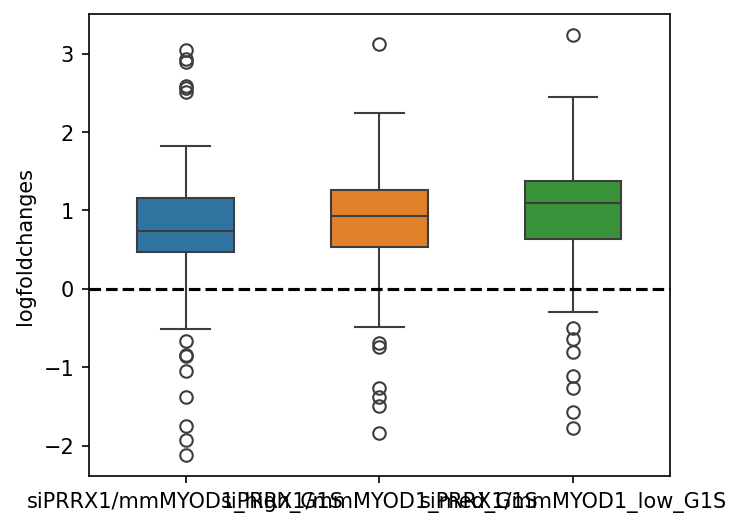

In [130]:
plt.figure(figsize=(5, 4), dpi=150)

sns.boxplot(
    sig,
    x='group',
    y='logfoldchanges',
    # y='abs_lfc',
    hue='group',
    order=hue_order,
    hue_order=hue_order,
    width=0.5,
)

plt.axhline(y=0, ls='--', color='k')

plt.xlabel("")
# plt.ylabel("Absolute logfoldchange")

plt.show()

In [131]:
# groups_keep = ["mmMYOD1_low", "mmMYOD1_med", "mmMYOD1_high"]
groups_keep = [f'{group_key}_low_G1S', f'{group_key}_med_G1S', f'{group_key}_high_G1S']

direction = 'up'

tmp = sig[sig['direction'] == direction].copy()


wdf = (
    tmp.loc[tmp["group"].isin(groups_keep), ["names", "group", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "group"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="group", values="logfoldchanges")
      .rename(columns={
          f'{group_key}_low_G1S':  "logFC_low",
          f'{group_key}_med_G1S':  "logFC_med",
          f'{group_key}_high_G1S': "logFC_high",
      })
)

if direction == 'down':
    wdf = wdf.abs()

print(wdf.shape)
wdf.head()

(147, 3)


group,logFC_high,logFC_low,logFC_med
names,,,
AMBRA1,0.352570,0.410944,0.345346
ANLN,0.962626,1.654035,1.445059
ANP32E,NaN,1.009151,0.773258
ARPP19,NaN,0.234309,NaN
ATAD2,0.587634,1.300142,0.992138


(84, 4)


group,logFC_high,logFC_low,logFC_med,delta_high_low
names,,,,
AMBRA1,0.352570,0.410944,0.345346,-0.058374
ANLN,0.962626,1.654035,1.445059,-0.691409
ATAD2,0.587634,1.300142,0.992138,-0.712507
AURKA,1.208201,1.267594,1.263712,-0.059392
BIRC5,0.621688,1.643880,1.554527,-1.022192


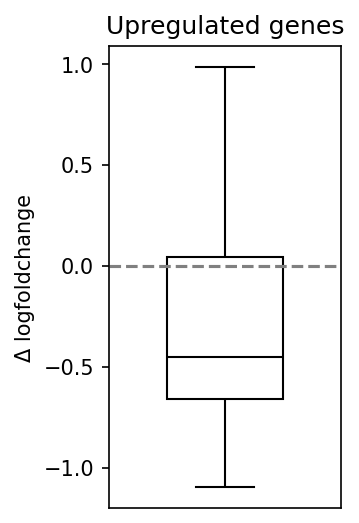

In [132]:
wdf1 = wdf.dropna(subset=['logFC_low', 'logFC_high']).copy()
wdf1['delta_high_low'] = wdf1['logFC_high'] - wdf1['logFC_low']

print(wdf1.shape)
display(wdf1.head())

plt.figure(figsize=(2, 4), dpi=150)

sns.boxplot(
    wdf1,
    y='delta_high_low',
    width=0.5,
    color='white',
    linecolor='k',
    showfliers=False,
)

plt.ylabel("Δ logfoldchange")
plt.gca().tick_params(axis='x', bottom=False)

plt.axhline(y=0, ls='--', color='gray')

if direction == 'up':
    plt.title("Upregulated genes")
    
if direction == 'down':
    plt.title("Downregulated genes")
    
plt.show()

In [133]:
display(wdf1.sort_values(by='delta_high_low', ascending=False).head())
display(wdf1.sort_values(by='delta_high_low', ascending=True).head())

group,logFC_high,logFC_low,logFC_med,delta_high_low
names,,,,
PLK2,2.928978,1.779167,2.239594,1.149811
GAS2L3,2.897106,1.911711,2.032273,0.985395
MYC,1.827079,0.846664,1.172975,0.980415
CHEK2,3.043837,2.141956,2.233292,0.901881
SPDYA,2.567629,1.723351,1.931981,0.844278


group,logFC_high,logFC_low,logFC_med,delta_high_low
names,,,,
CCNA2,0.507779,1.604029,1.267331,-1.096249
BIRC5,0.621688,1.643880,1.554527,-1.022192
MKI67,1.179325,2.168933,1.799213,-0.989608
CLSPN,0.696604,1.632021,1.290719,-0.935417
CDC6,1.229881,2.145162,1.746718,-0.915281


In [134]:
groups_keep = [f'{group_key}_low_G1S', f'{group_key}_high_G1S']

kdf = sig[sig['group'].isin(groups_keep)].copy()
print(kdf.shape)


# Step 1: build a per-gene summary of directions across groups
gene_summary = (
    kdf.groupby('names')
      .agg(
          n_groups=('group', 'nunique'),
          n_directions=('direction', lambda x: x.nunique()),
          direction_set=('direction', lambda x: set(x))
      )
      .reset_index()
)

# Step 2: define logic for consistency
def classify(row):
    if row['n_groups'] == 1:
        return 'unique_to_group'
    elif row['n_directions'] == 1:
        return 'match'
    else:
        return 'mismatch'

gene_summary['direction_consistency'] = gene_summary.apply(classify, axis=1)

# Step 3: map back to original dataframe
kdf = kdf.merge(
    gene_summary[['names', 'direction_consistency']],
    on='names',
    how='left'
)

kdf.head()

(257, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,direction,abs_lfc,direction_consistency
0,siPRRX1/mmMYOD1_high_G1S,GMNN,30.881842,2.588793,2.094333e-209,3.898252e-207,0.841031,up,2.588793,match
1,siPRRX1/mmMYOD1_high_G1S,PLK2,18.937969,2.928978,5.549692e-80,3.051481e-78,0.545650,up,2.928978,match
2,siPRRX1/mmMYOD1_high_G1S,FBXL7,17.425318,1.163699,5.301234e-68,2.332914e-66,0.789474,up,1.163699,match
3,siPRRX1/mmMYOD1_high_G1S,CDKN1A,15.276446,1.320675,1.097657e-52,3.742460e-51,0.722879,up,1.320675,match
4,siPRRX1/mmMYOD1_high_G1S,BRIP1,14.790622,1.593779,1.683921e-49,5.342623e-48,0.544576,up,1.593779,match


In [135]:
print(kdf['names'].nunique())

print("\n", kdf.groupby('group')['names'].nunique())

print("\n", kdf.groupby(['group', 'direction'])['names'].nunique())

157

 group
siPRRX1/mmMYOD1_high_G1S    109
siPRRX1/mmMYOD1_low_G1S     148
Name: names, dtype: int64

 group                     direction
siPRRX1/mmMYOD1_high_G1S  down          18
                          up            91
siPRRX1/mmMYOD1_low_G1S   down          13
                          up           135
Name: names, dtype: int64


In [ ]:
high = kdf[kdf['group'] == 'siPRRX1/mmMYOD1_high_G1S']['names'].

In [109]:
print(kdf.groupby('group')['direction_consistency'].value_counts())

group                     direction_consistency
siPRRX1/mmMYOD1_high_G1S  match                    97
                          unique_to_group           9
                          mismatch                  3
siPRRX1/mmMYOD1_low_G1S   match                    97
                          unique_to_group          48
                          mismatch                  3
Name: count, dtype: int64


In [110]:
mdf = kdf[kdf['direction_consistency'] == 'mismatch'].copy()

mdf.head()

mdf = mdf.pivot(index='names', columns='group', values="logfoldchanges")
mdf.index.name = None
mdf.columns.name = None
display(mdf)

,siPRRX1/mmMYOD1_high_G1S,siPRRX1/mmMYOD1_low_G1S
CALM1,-0.137763,0.225949
CBX5,-0.184077,0.316714
KHDRBS1,-0.143933,0.308158


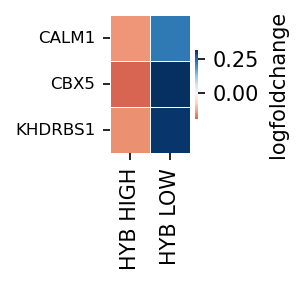

In [115]:
vmin = (mdf.min()).min()
vmax = (mdf.max()).max()

plt.figure(figsize=(2, 2), dpi=150)#max(6, 0.25 * len(mat))))  # scale height with #genes
ax = sns.heatmap(
    mdf,
    # cmap=custom_cmap,
    cmap="RdBu",
    linewidths=0.35,
    linecolor="white",
    cbar_kws={"label": "logfoldchange", 'shrink': 0.5},
    vmin=vmin,
    vmax=vmax,
    center=0,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(["HYB HIGH", "HYB LOW"], rotation=90)

ax.set_yticks([i + 0.5 for i in range(len(mdf))])
ax.set_yticklabels(mdf.index.to_list(), fontsize=8, va='center')


plt.tight_layout()
plt.show()

In [114]:
# groups_keep = ["mmMYOD1_low", "mmMYOD1_high"]

direction = 'up'

tmp = sig[sig['direction'] == direction].copy()


wdf = (
    tmp.loc[tmp["group"].isin(groups_keep), ["names", "group", "logfoldchanges"]]
      .drop_duplicates(subset=["names", "group"])   # in case a gene appears twice for a group
      .pivot(index="names", columns="group", values="logfoldchanges")
      .rename(columns={
          f'{group_key}_low_G1S':  "logFC_low",
          f'{group_key}_med_G1S':  "logFC_med",
          f'{group_key}_high_G1S': "logFC_high",
      })
)

# # optional: keep only genes present in all three groups
# wide_all3 = wdf.dropna(subset=["logFC_low", "logFC_med", "logFC_high"])
# print(wide_all3.shape)

if direction == 'down':
    wdf = wdf.abs()

print(wdf.shape)
wdf.head()

wdf1 = wdf.dropna(subset=['logFC_low', 'logFC_high']).copy()

print(wdf1.shape)

wdf1['delta_high_low'] = wdf1['logFC_high'] - wdf1['logFC_low']

wdf1['pos_delta'] = wdf1['delta_high_low'] > 0

print(wdf1['pos_delta'].value_counts(normalize=True))
wdf1.head()

(142, 2)
(84, 2)
pos_delta
False    0.714286
True     0.285714
Name: proportion, dtype: float64


group,logFC_high,logFC_low,delta_high_low,pos_delta
names,,,,
AMBRA1,0.352570,0.410944,-0.058374,False
ANLN,0.962626,1.654035,-0.691409,False
ATAD2,0.587634,1.300142,-0.712507,False
AURKA,1.208201,1.267594,-0.059392,False
BIRC5,0.621688,1.643880,-1.022192,False


# By phase

In [15]:
# # Create a collapsed phase column
# adata.obs['phase_grouped'] = adata.obs['phase'].replace({
#     'G1': 'G1S',
#     'S': 'G1S',
#     'G2M': 'G2M'
# })

# Create the combined grouping column
adata.obs['exp_phase'] = (
    adata.obs['exp_level_group'].astype(str) + '_' +
    adata.obs['phase'].astype(str)
)

adata.obs["exp_phase"].value_counts(sort=False)

exp_phase
siPRRX1/mmMYOD1_high_G2M     190
mmMYOD1_med_S                170
siPRRX1/mmMYOD1_med_G1       547
siPRRX1_NE_G2M              1179
mmMYOD1_med_G1               465
mmMYOD1_low_G2M              133
siPRRX1_NE_G1               1164
siPRRX1/mmMYOD1_low_S        339
siPRRX1/mmMYOD1_low_G1       469
siPRRX1_med_G1               103
siPRRX1_NE_S                 561
siPRRX1_high_G1              113
siPRRX1/mmMYOD1_med_S        295
siPRRX1/mmMYOD1_med_G2M      278
mmMYOD1_high_G1              565
siPRRX1_low_G1               112
siPRRX1/mmMYOD1_high_G1      714
mmMYOD1_low_G1               422
siPRRX1/mmMYOD1_high_S       217
mmMYOD1_high_S               100
mmMYOD1_med_G2M              113
siPRRX1/mmMYOD1_low_G2M      313
mmMYOD1_high_G2M              84
siPRRX1_med_S                 54
mmMYOD1_NE_G1                  6
siPRRX1_high_G2M              99
siPRRX1/mmMYOD1_NE_S          17
siPRRX1/mmMYOD1_NE_G1         40
siPRRX1_med_G2M              102
mmMYOD1_low_S                193


In [31]:
groups = adata.obs[['exp_phase']].copy()
groups = groups.reset_index(names='cell_id')
print(groups.shape)

tmp = pd.merge(df1, groups, how='left', on='cell_id')

tmp['exp_level'] = tmp['exp_phase'].str.split('_').str[-2].str.upper()
tmp['phase_group'] = tmp['exp_phase'].str.split('_').str[-1].str.upper()

print(tmp.shape)
tmp.head()

(16296, 2)
(16296, 9)


,cell_id,MYOD1_exo,MYOD1_endo,pooled_condition,leiden_split,phase,exp_phase,exp_level,phase_group
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,siPRRX1/mmMYOD1,H1,G2M,siPRRX1/mmMYOD1_high_G2M,HIGH,G2M
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,mmMYOD1,M1,S,mmMYOD1_med_S,MED,S
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,siPRRX1/mmMYOD1,H1,G1,siPRRX1/mmMYOD1_med_G1,MED,G1
3,AAACCATTCACGTAAT_hybrid,0.000000,0.000000,siPRRX1,P1,G2M,siPRRX1_NE_G2M,NE,G2M
4,AAACCATTCAGGCAGA_hybrid,0.000000,0.000000,siPRRX1,P1,G2M,siPRRX1_NE_G2M,NE,G2M


In [32]:
conds = ['mmMYOD1', 'siPRRX1/mmMYOD1', 'Control']

for c in conds:
    t1 = tmp[tmp['pooled_condition'] == c]
    print(f'{c}:')
    display(t1.groupby('exp_level')['phase_group'].value_counts())
    print('\n')
    
    # break

mmMYOD1:


exp_level  phase_group
HIGH       G1             565
           S              100
           G2M             84
LOW        G1             422
           S              193
           G2M            133
MED        G1             465
           S              170
           G2M            113
NE         G1               6
           S                3
           G2M              1
Name: count, dtype: int64



siPRRX1/mmMYOD1:


exp_level  phase_group
HIGH       G1             714
           S              217
           G2M            190
LOW        G1             469
           S              339
           G2M            313
MED        G1             547
           S              295
           G2M            278
NE         G1              40
           G2M             37
           S               17
Name: count, dtype: int64



Control:


exp_level  phase_group
CONTROL    G1             3527
           G2M            2980
           S               395
Name: count, dtype: int64

In [33]:
print(tmp.shape)
tmp.head()

(16296, 9)


,cell_id,MYOD1_exo,MYOD1_endo,pooled_condition,leiden_split,phase,exp_phase,exp_level,phase_group
0,AAACCAAAGCAACTGC_hybrid,3.913242,3.309699,siPRRX1/mmMYOD1,H1,G2M,siPRRX1/mmMYOD1_high_G2M,HIGH,G2M
1,AAACCAAAGTAGGGCA_hybrid,3.809541,3.160314,mmMYOD1,M1,S,mmMYOD1_med_S,MED,S
2,AAACCAAAGTCTAGGC_hybrid,2.587936,2.244517,siPRRX1/mmMYOD1,H1,G1,siPRRX1/mmMYOD1_med_G1,MED,G1
3,AAACCATTCACGTAAT_hybrid,0.000000,0.000000,siPRRX1,P1,G2M,siPRRX1_NE_G2M,NE,G2M
4,AAACCATTCAGGCAGA_hybrid,0.000000,0.000000,siPRRX1,P1,G2M,siPRRX1_NE_G2M,NE,G2M


In [27]:
# count cells per group

tmp1 = tmp[tmp['pooled_condition'].isin(['mmMYOD1', 'siPRRX1/mmMYOD1'])].copy()

counts = (
    tmp1.groupby(['pooled_condition', 'exp_level', 'phase'], observed=True)
      .size()
      .reset_index(name='n')
)

# compute proportions within each condition + exp_level
counts['prop'] = (
    counts.groupby(['pooled_condition', 'exp_level'], observed=True)['n']
          .transform(lambda x: x / x.sum())
)

display(counts.head())

plot_df = counts.pivot_table(
    index=['pooled_condition', 'exp_level'],
    columns='phase',
    values='prop',
    fill_value=0
)

plot_df

,pooled_condition,exp_level,phase,n,prop
0,mmMYOD1,HIGH,G1,565,0.754339
1,mmMYOD1,HIGH,G2M,84,0.112150
2,mmMYOD1,HIGH,S,100,0.133511
3,mmMYOD1,LOW,G1,422,0.564171
4,mmMYOD1,LOW,G2M,133,0.177807


/tmp/ipykernel_1396801/3729229871.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_df = counts.pivot_table(


phase                             G1       G2M         S
pooled_condition exp_level                              
mmMYOD1          HIGH       0.754339  0.112150  0.133511
                 LOW        0.564171  0.177807  0.258021
                 MED        0.621658  0.151070  0.227273
                 NE         0.600000  0.100000  0.300000
siPRRX1/mmMYOD1  HIGH       0.636931  0.169492  0.193577
                 LOW        0.418376  0.279215  0.302409
                 MED        0.488393  0.248214  0.263393
                 NE         0.425532  0.393617  0.180851

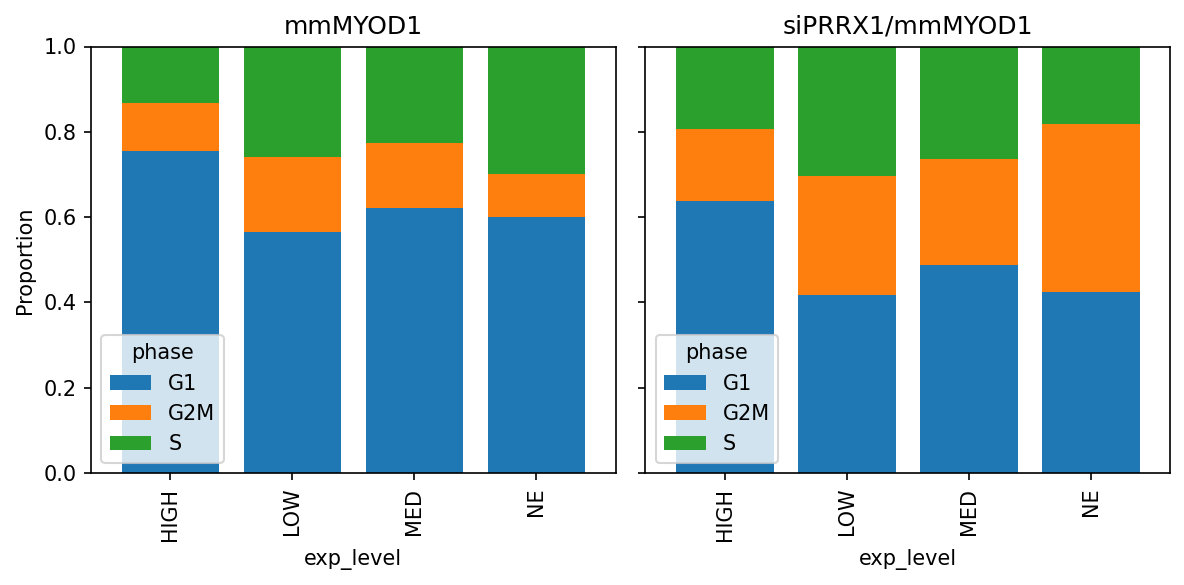

In [28]:
conditions = plot_df.index.get_level_values('pooled_condition').unique()

fig, axes = plt.subplots(1, len(conditions), figsize=(8, 4), sharey=True)

if len(conditions) == 1:
    axes = [axes]

for ax, cond in zip(axes, conditions):
    tmp2 = plot_df.loc[cond]

    tmp2.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        width=0.8
    )

    ax.set_title(cond)
    ax.set_xlabel('exp_level')
    ax.set_ylabel('Proportion')
    ax.set_ylim(0, 1)
    ax.legend(title='phase')

plt.tight_layout()
plt.show()

In [38]:
# CDK2 levels

adata.X = adata.layers['log_norm'].copy()


genes = ['CDK2']

mdata = adata[:, genes].copy()
print(mdata.shape)


X = mdata.X if isinstance(mdata.X, np.ndarray) else mdata.X.toarray()

df = pd.DataFrame(
        X,
        index=mdata.obs_names,
        columns=mdata.var_names,
    )


df = df.reset_index(names='cell_id')
print(df.shape)
df.head()


tmp = adata.obs[['pooled_condition', 'leiden_split', 'phase', 'exp_level']].copy()

tmp = tmp.reset_index(names='cell_id')


df1 = pd.merge(df, tmp, how='left', on='cell_id')
print(df1.shape)
df1.head()

(16296, 1)
(16296, 2)
(16296, 6)


,cell_id,CDK2,pooled_condition,leiden_split,phase,exp_level
0,AAACCAAAGCAACTGC_hybrid,0.423657,siPRRX1/mmMYOD1,H1,G2M,high
1,AAACCAAAGTAGGGCA_hybrid,0.706198,mmMYOD1,M1,S,med
2,AAACCAAAGTCTAGGC_hybrid,0.000000,siPRRX1/mmMYOD1,H1,G1,med
3,AAACCATTCACGTAAT_hybrid,0.000000,siPRRX1,P1,G2M,NE
4,AAACCATTCAGGCAGA_hybrid,0.433809,siPRRX1,P1,G2M,NE


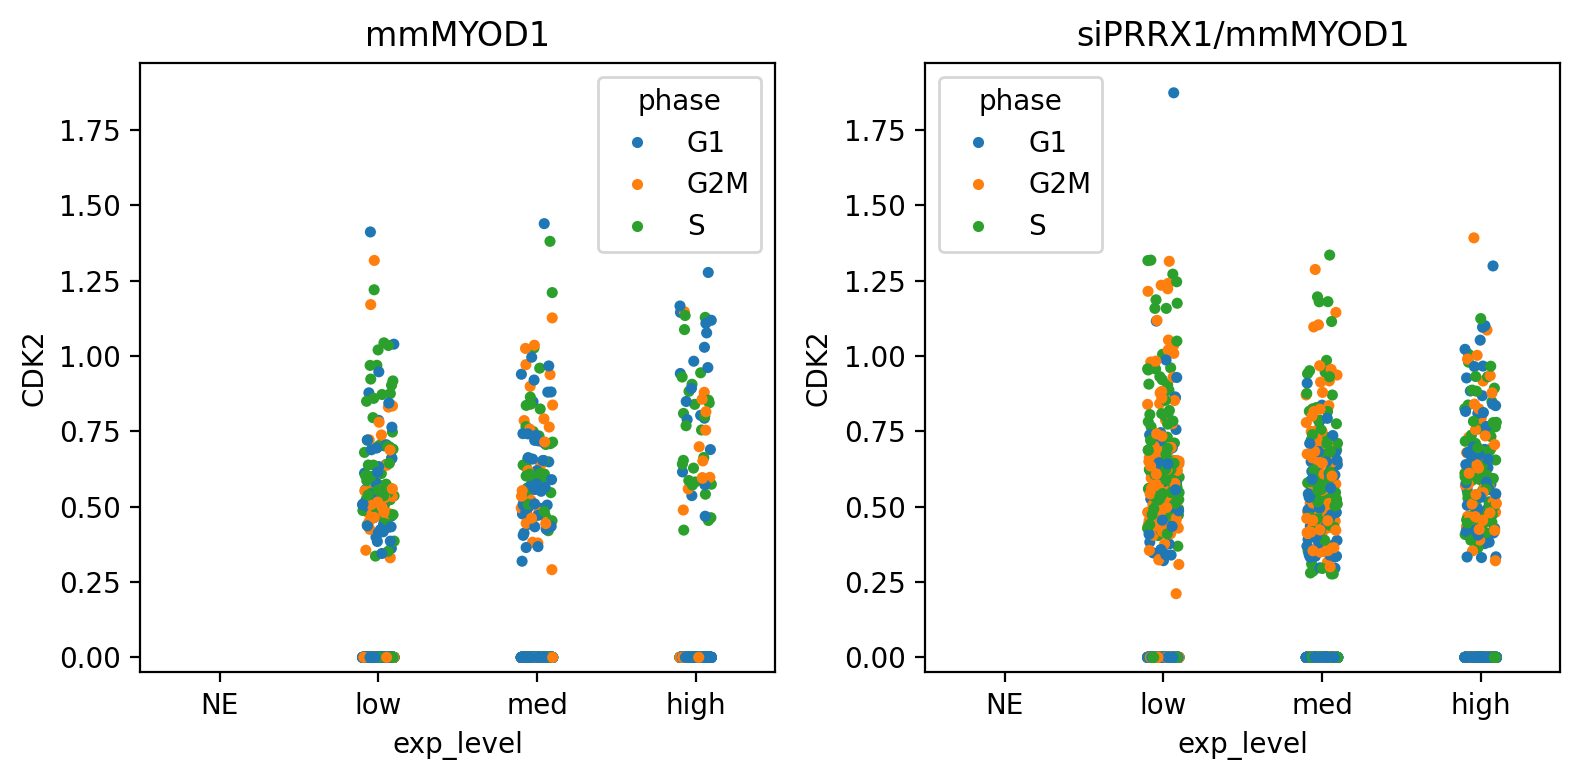

In [54]:
conds = ['mmMYOD1', 'siPRRX1/mmMYOD1']

max_val = df1['CDK2'].max()

fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes = axes.flatten()

for i, cond in enumerate(conds):
    ax = axes[i]
    
    tmp = df1[df1['pooled_condition'] == cond].copy()
    tmp = tmp[tmp['exp_level'] != 'NE']
    
    sns.stripplot(
        data=tmp,
        x='exp_level',
        y='CDK2',
        hue='phase',
        ax=ax,
        s=4,
    )
    
    ax.set_title(f'{cond}')
    ax.set_ylim(-0.05, max_val+0.1)

plt.tight_layout()
plt.show()

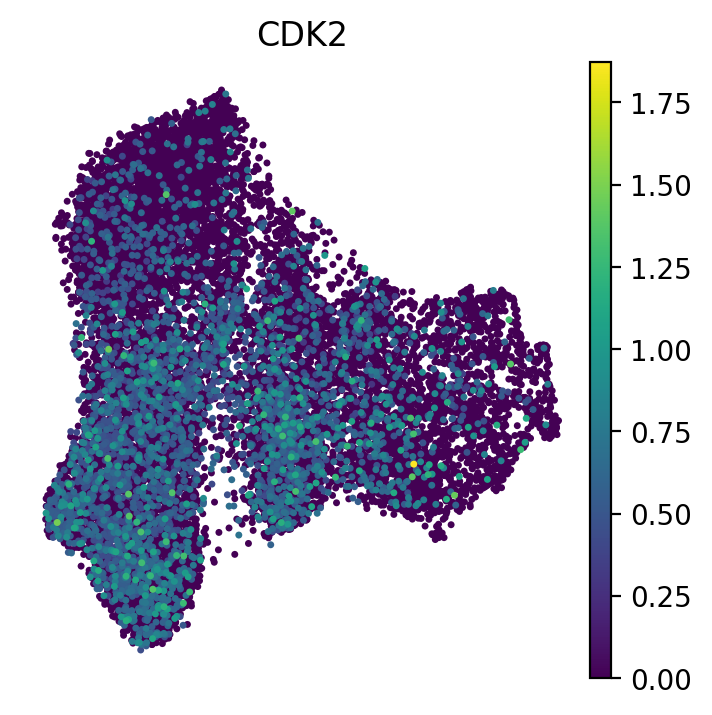

In [37]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color='CDK2',
    size=25,
    frameon=False,
    alpha=1,
    layer='log_norm',
)

plt.show()

In [ ]:
# same genes or unique?

# high_set = sig[sig['group'] == 'mmMYOD1_high']['names'].unique()
# med_set = sig[sig['group'] == 'mmMYOD1_med']['names'].unique()
# low_set = sig[sig['group'] == 'mmMYOD1_low']['names'].unique()



# is magnitude of effect greater for the same genes?



['#393b79',
 '#5254a3',
 '#9c9ede',
 '#8ca252',
 '#cedb9c',
 '#bd9e39',
 '#e7ba52',
 '#843c39',
 '#d6616b',
 '#7b4173',
 '#ce6dbd',
 '#de9ed6']

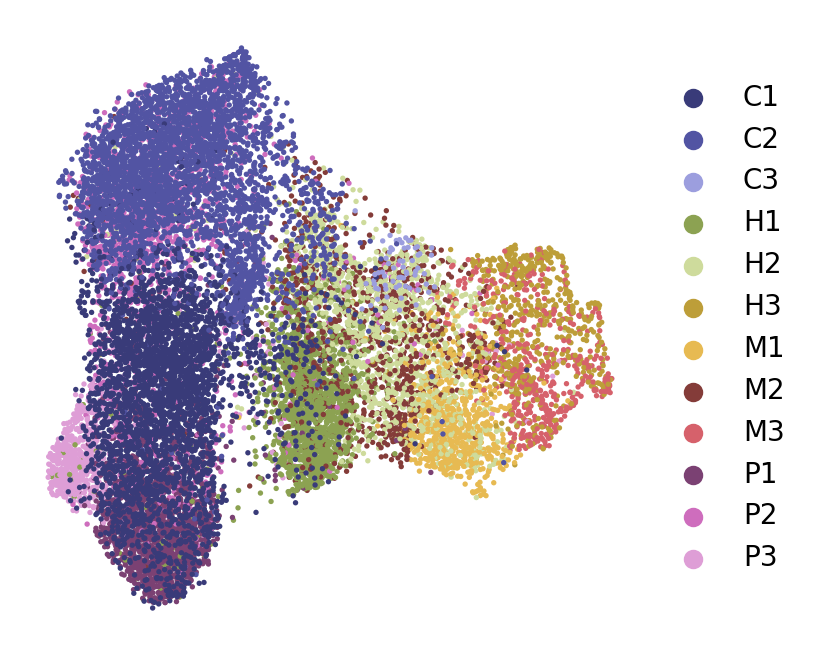

In [3]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color='leiden_split',
    size=15,
    frameon=False,
    alpha=1,
    palette='tab20b',
    show=False,
    title='',
    # legend_loc='on data',
)

adata.uns['leiden_split_colors'] = sc.pl.palettes.default_20 if 'leiden_split_colors' not in adata.uns else adata.uns['leiden_split_colors']
adata.uns['leiden_split_colors'] 

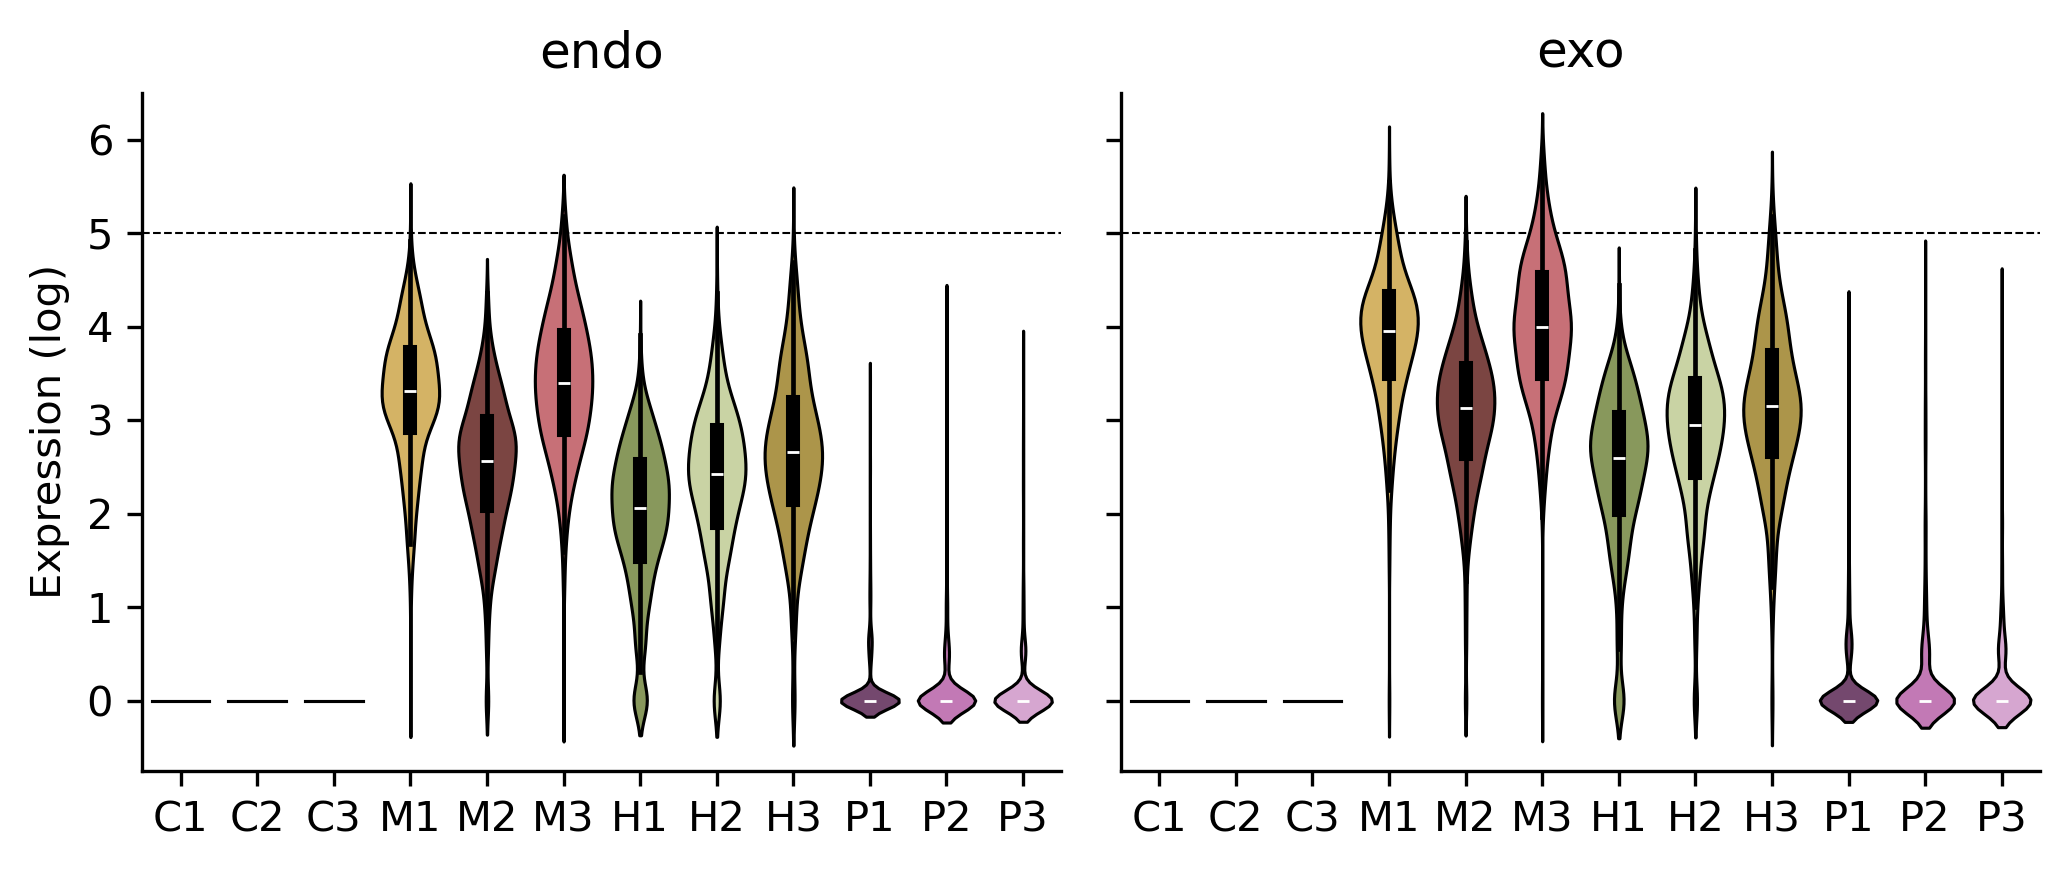

In [4]:
genes_to_plot = ['MYOD1_endo', 'MYOD1_exo']

plot_order = [
    'C1', 'C2', 'C3',
    'M1', 'M2', 'M3',
    'H1', 'H2', 'H3',
    'P1', 'P2', 'P3',
]

cat_order = adata.obs['leiden_split'].cat.categories
color_map = dict(zip(cat_order, adata.uns['leiden_split_colors']))
palette = {k: color_map[k] for k in plot_order}

fig, axes = plt.subplots(1, 2, figsize=(7, 3), dpi=300, sharey=True)

layer = 'log_norm'

for i, gene in enumerate(genes_to_plot):
    adata.X = adata.layers[layer].copy()
    gene_exp = adata[:, gene].X.toarray().flatten()
    groups = adata.obs['leiden_split']
    data = pd.DataFrame({'expression': gene_exp, 'group': groups})

    sns.violinplot(
        data=data,
        x='group',
        y='expression',
        hue='group',
        order=plot_order,
        hue_order=plot_order,
        width=0.75,
        linewidth=0.75,
        linecolor='k',
        # palette=adata.uns['leiden_split_colors'],
        palette=palette,
        ax=axes[i],
        legend=False,
    )
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=0)
    
    axes[i].set_title(gene.split('_')[1])
    
    if layer == 'log_norm':
        axes[i].set_ylabel("Expression (log)")
        axes[i].axhline(y=5, ls='--', color='k', lw=0.5, zorder=0)
    else:
        axes[i].set_ylabel("Raw counts")
    # axes[i].set_title(gene)
    axes[i].set_ylim([-0.75, 6.5])
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

count    6385.000000
mean        0.562742
std         0.197532
min         0.000000
25%         0.478261
50%         0.565217
75%         0.666667
max         1.000000
Name: MYOD1_endo_exo_ratio, dtype: float64

(16296, 39)
(6385, 39)


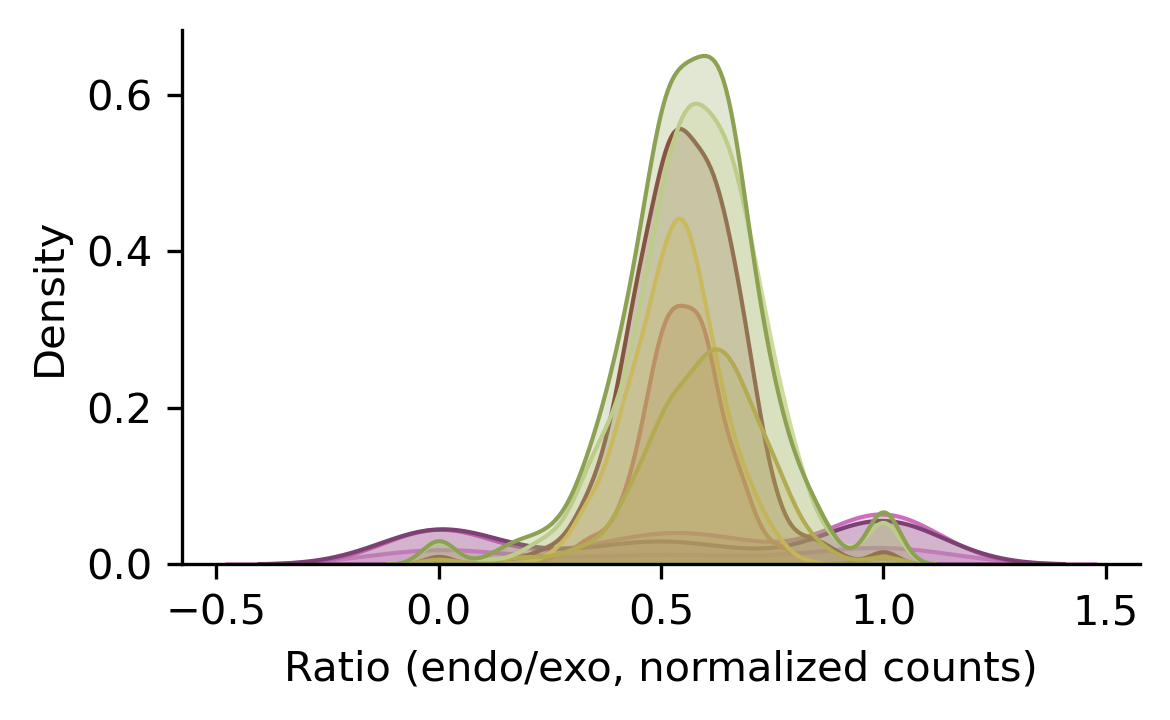

In [5]:
# compute ratio of exo and endo
endo_idx = adata.var_names.get_loc('MYOD1_endo')
exo_idx  = adata.var_names.get_loc('MYOD1_exo')

layer = 'norm'

expr = adata.layers[layer]
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()

endo_exp = expr[:, endo_idx]
exo_exp  = expr[:, exo_idx]

# Calculate ratio safely (NaN where exo is 0)
ratio = np.divide(endo_exp, exo_exp, out=np.full_like(endo_exp, np.nan), where=exo_exp!=0)

adata.obs['MYOD1_endo_exo_ratio'] = ratio

# display(adata_expanded.obs.head())
display(adata.obs['MYOD1_endo_exo_ratio'].describe())

# colors = {'Control': '#D3D4D8', 'mmMYOD1': '#C52E19', 'siPRRX1/mmMYOD1': '#FBA72A', 'siPRRX1': '#5785C1'}

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 2.5

df = adata.obs.copy()
print(df.shape)
df = adata.obs.dropna(subset='MYOD1_endo_exo_ratio')
print(df.shape)

sns.kdeplot(
    # data=adata_expanded.obs,
    data=df,
    x='MYOD1_endo_exo_ratio',
    fill=True,
    hue='leiden_split',
    palette=palette,
    legend=False,
)

plt.xlabel("Ratio (endo/exo, normalized counts)")

sns.despine()
plt.tight_layout()
plt.show()

In [6]:
tmp = df.copy()

tmp = tmp[['pooled_condition', 'leiden_split', 'phase', 'MYOD1_endo_exo_ratio']]

tmp = tmp[tmp['pooled_condition'] != 'siPRRX1']

tmp['pooled_condition'] = tmp['pooled_condition'].astype(str)
tmp['leiden_split'] = tmp['leiden_split'].astype(str)

tmp.head()

,pooled_condition,leiden_split,phase,MYOD1_endo_exo_ratio
AAACCAAAGCAACTGC_hybrid,siPRRX1/mmMYOD1,H1,G2M,0.537634
AAACCAAAGTAGGGCA_hybrid,mmMYOD1,M1,S,0.511628
AAACCAAAGTCTAGGC_hybrid,siPRRX1/mmMYOD1,H1,G1,0.685714
AAACCATTCCGTAATG_hybrid,siPRRX1/mmMYOD1,H2,G2M,0.578947
AAACCCGCACCATAGG_hybrid,mmMYOD1,M2,G1,0.689655


In [7]:
tmp['pooled_condition'].value_counts()

pooled_condition
siPRRX1/mmMYOD1    3362
mmMYOD1            2245
Name: count, dtype: int64

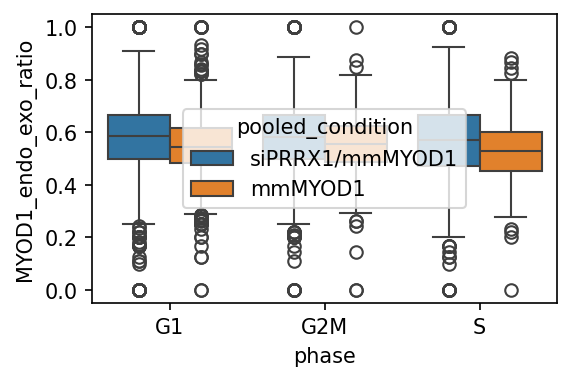

In [8]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2.5

sns.boxplot(
    tmp,
    x='phase',
    y='MYOD1_endo_exo_ratio',
    hue='pooled_condition',
)


plt.show()

In [9]:
groups = [g['MYOD1_endo_exo_ratio'].values 
          for _, g in tmp.groupby('phase')]

h_stat, p_val = stats.kruskal(*groups)
print(h_stat, p_val)

n = len(tmp)
k = tmp['phase'].nunique()

eta_squared = (h_stat - k + 1) / (n - k)
print(eta_squared)

12.135554900940342 0.0023163156200477135
0.0018086286404247576


/tmp/ipykernel_3406139/860916241.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in tmp.groupby('phase')]


In [10]:
for cond, subdf in tmp.groupby('pooled_condition'):
    groups = [g['MYOD1_endo_exo_ratio'].values 
              for _, g in subdf.groupby('phase')]
    print(cond, stats.kruskal(*groups))

mmMYOD1 KruskalResult(statistic=np.float64(13.92937385020216), pvalue=np.float64(0.0009446586382439302))
siPRRX1/mmMYOD1 KruskalResult(statistic=np.float64(5.5275704183107885), pvalue=np.float64(0.06305264862319761))


/tmp/ipykernel_3406139/2817081382.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for _, g in subdf.groupby('phase')]


In [12]:
model = smf.ols(
    'MYOD1_endo_exo_ratio ~ C(phase) + C(pooled_condition) + C(leiden_split)',
    data=tmp
).fit()

print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     MYOD1_endo_exo_ratio   R-squared:                       0.019
Model:                              OLS   Adj. R-squared:                  0.018
Method:                   Least Squares   F-statistic:                     15.59
Date:                  Wed, 22 Apr 2026   Prob (F-statistic):           2.25e-20
Time:                          17:37:09   Log-Likelihood:                 3015.7
No. Observations:                  5607   AIC:                            -6015.
Df Residuals:                      5599   BIC:                            -5962.
Df Model:                             7                                         
Covariance Type:              nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [13]:
for cond, subdf in tmp.groupby('pooled_condition'):
    model = smf.ols(
        'MYOD1_endo_exo_ratio ~ C(phase)',
        data=subdf
    ).fit()
    print(cond)
    print(model.summary())

mmMYOD1
                             OLS Regression Results                             
Dep. Variable:     MYOD1_endo_exo_ratio   R-squared:                       0.004
Model:                              OLS   Adj. R-squared:                  0.004
Method:                   Least Squares   F-statistic:                     5.045
Date:                  Wed, 22 Apr 2026   Prob (F-statistic):            0.00652
Time:                          17:37:11   Log-Likelihood:                 1690.6
No. Observations:                  2245   AIC:                            -3375.
Df Residuals:                      2242   BIC:                            -3358.
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept     